<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/DataCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### SECTION 1: IMPORT LIBRARIES

In [4]:
#---------------RIYA----------------#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
from scipy import stats
import os

#---------------MANASA----------------#

from datetime import datetime
from sklearn.impute import SimpleImputer
import chardet
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

#---------------NICOKLE----------------#

import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycountry", "unidecode"])
import re
import math
import pycountry
from unidecode import unidecode


#### SECTION 2: DATA LOADING AND INITIAL SETUP

In [5]:
#---------------MANASA----------------#

# Reading the encoding from the source file to help with UTF decoding errors observed during type coercion and encoding
fileName = '/content/GamingStudy_data.csv'
with open(fileName, 'rb') as f:
        raw_data = f.read(10000) # Read a sample of the file
        result = chardet.detect(raw_data)
        file_encoding = result['encoding']


gamers_csv = pd.read_csv(fileName,
                         encoding=file_encoding,
                         engine='python',
                         keep_default_na=False)
pd.set_option('display.max_columns', None)
gamers_csv

,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Game,Platform,Hours,earnings,whyplay,League,highestleague,streams,SPIN1,SPIN2,SPIN3,SPIN4,SPIN5,SPIN6,SPIN7,SPIN8,SPIN9,SPIN10,SPIN11,SPIN12,SPIN13,SPIN14,SPIN15,SPIN16,SPIN17,Narcissism,Gender,Age,Work,Degree,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,3,5,5,5,5,Skyrim,"Console (PS, Xbox, ...)",15,I play for fun,having fun,N/A,NA,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,Male,25,Unemployed / between jobs,Bachelor (or equivalent),USA,USA,Reddit,Singleplayer,Accept,1,23,5,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,3,5,2,5,1,Other,PC,8,I play for fun,having fun,N/A,NA,2,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,1,Male,41,Unemployed / between jobs,Bachelor (or equivalent),USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,2,6,5,2,2,Other,PC,0,I play for fun,having fun,n/a,NA,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,4,Female,32,Employed,Bachelor (or equivalent),Germany,Germany,Reddit,Singleplayer,Accept,8,17,31,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,Other,PC,20,I play for fun,improving,N/A,NA,5,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,2,Male,28,Employed,Bachelor (or equivalent),USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,2,2,4,5,1,Other,"Console (PS, Xbox, ...)",20,I play for fun,having fun,n/a,NA,1,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,1,Male,19,Employed,High school diploma (or equivalent),USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13,KOR,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13459,14246,42057.75678,1,0,0,1,0,1,1,Not difficult at all,6,6,5,5,6,Other,"Console (PS, Xbox, ...)",40,I play for fun,improving,NA,NA,10,1,1,1,2,1,0,0,0,0,0,0,0,0,0,1,0,0,3,Male,22,Student at college / university,Master (or equivalent),France,France,Reddit,Multiplayer - online - with strangers,Accept,4,28,7,FRA,FRA
13460,14247,42057.81185,3,3,3,3,2,3,3,Extremely difficult,5,5,5,4,4,League of Legends,PC,20,I play for fun,winning,NA,NA,20,0,1,2,2,0,1,3,3,2,1,4,0,2,2,1,0,1,2,Female,20,Student at college / university,High school diploma (or equivalent),USA,USA,Reddit,Multiplayer - online - with strangers,Accept,20,23,25,USA,USA
13461,14248,42058.16964,0,0,0,0,0,0,0,Not difficult at all,6,6,7,7,6,Starcraft 2,PC,20,I play for fun,having fun,Gold,NA,14,0,1,0,2,0,1,0,2,0,1,1,1,0,1,0,0,0,2,Male,19,Student at college / university,High school diploma (or equivalent),Norway,Norway,Reddit,Multiplayer - online - with real life friends,Accept,0,32,10,NOR,NOR
13462,14249,42058.24420,3,2,1,3,0,1,3,Somewhat difficult,2,6,3,2,3,Other,"Console (PS, Xbox, ...)",5,I play for fun,having fun,NA,NA,0,0,1,3,2,3,4,1,3,4,1,3,1,0,3,2,0,1,2,Female,18,Student at school,High school diploma (or equivalent),Canada,Canada,Reddit,Singleplayer,Accept,13,16,32,CAN,CAN


#### SECTION 3: REMOVE UNNECESSARY COLUMNS AND ROWS

In [6]:
#---------MING----------------#

# Columns to remove
columns_to_remove = [
    'Timestamp',
    'highestleague',
    'Birthplace',
    'Residence',
    'accept',
    'Reference'
]

# Remove columns that exist in the dataframe
for col in columns_to_remove:
    if col in gamers_csv.columns:
        gamers_csv.drop(columns=[col], inplace=True)

print(f"Columns removed. Remaining columns: {len(gamers_csv.columns)}")

#---------MANASA----------------#

gamers_csv['Narcissism'] = gamers_csv['Narcissism'].astype(str).str.strip()
gamers_csv['Work'] = gamers_csv['Work'].astype(str).str.strip()

# Store original count
original_count = len(gamers_csv)
print(f"Starting rows: {original_count}")

# Remove rows with 'NA' in narcissism column
gamers_csv = gamers_csv[gamers_csv['Narcissism'] != 'NA']
print(f"  - Removed {original_count - len(gamers_csv)} rows (narcissism = 'NA')")

# Remove rows with 'NA' in work column
temp_count = len(gamers_csv)
gamers_csv = gamers_csv[gamers_csv['Work'] != 'NA']
print(f"  - Removed {temp_count - len(gamers_csv)} rows (Work = 'NA')")

print(f"\nFinal rows: {len(gamers_csv)} (removed {original_count - len(gamers_csv)} total)")

Columns removed. Remaining columns: 49
Starting rows: 13464
  - Removed 23 rows (narcissism = 'NA')
  - Removed 34 rows (Work = 'NA')

Final rows: 13407 (removed 57 total)


#### SECTION 4: GADE (ANXIETY) ENCODING

In [7]:
#---------MANASA----------------#

GADE_map = {
    "Not difficult at all": 0,
    "Somewhat difficult": 1,
    "Very difficult": 2,
    "Extremely difficult": 3,
    "NA": -1
}

# Create a NEW column with '_encoded' suffix to preserve the original
gamers_csv['GADE_encoded'] = gamers_csv['GADE'].map(GADE_map).astype(int)  # Added .astype(int)

# Verify the mapping
print(f"Original GADE values: {gamers_csv['GADE'].unique()}")
print(f"Encoded GADE values: {sorted(gamers_csv['GADE_encoded'].unique())}")  # Added sorted() for cleaner output
print(f"\nMapping verification:")
print(gamers_csv[['GADE', 'GADE_encoded']].drop_duplicates().sort_values('GADE_encoded'))

# Check for any unmapped values
unmapped = gamers_csv[gamers_csv['GADE_encoded'].isna()]['GADE'].unique()
if len(unmapped) > 0:
    print(f"\n Warning: Unmapped values found: {unmapped}")
else:
    print("\n All values successfully mapped!")

# logic for mapping all NA values to 0 after checking that most of the GAD_x values are 0
gad_cols = [col for col in gamers_csv.columns if col.startswith('GAD_')]

#pull all NA rows which are encoded as -1
cond_gad_na = (gamers_csv['GADE_encoded'] == -1)

rows_to_fill = cond_gad_na

# Apply the logic
gamers_csv.loc[cond_gad_na, 'GADE_encoded'] = 0

# print the number of rows changed
print(f"GADE updated to 0 for {rows_to_fill.sum()} rows.")

Original GADE values: ['Not difficult at all' 'Somewhat difficult' 'Very difficult' 'NA'
 'Extremely difficult']
Encoded GADE values: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Mapping verification:
                    GADE  GADE_encoded
7                     NA            -1
0   Not difficult at all             0
1     Somewhat difficult             1
4         Very difficult             2
21   Extremely difficult             3

 All values successfully mapped!
GADE updated to 0 for 647 rows.


#### SECTION 5: GAME ENCODING

In [8]:
#---------MING----------------#


game_mapping = {
    "Other": 0,
    "Skyrim": 1,
    "World of Warcraft": 2,
    "League of Legends": 3,
    "Starcraft 2": 4,
    "Counter Strike": 5,
    "Destiny": 6,
    "Diablo 3": 7,
    "Heroes of the Storm": 8,
    "Hearthstone": 9,
    "Guild Wars 2": 10,
    "NA": -1  # Add NA mapping
}

# Create a NEW column with '_encoded' suffix to preserve the original
gamers_csv['Game_encoded'] = gamers_csv['Game'].map(game_mapping).fillna(-1).astype(int)

# Verify the mapping
print(f"Original Game values: {gamers_csv['Game'].unique()}")
print(f"Encoded Game values: {sorted(gamers_csv['Game_encoded'].unique())}")
print(f"\nMapping verification:")
print(gamers_csv[['Game', 'Game_encoded']].drop_duplicates().sort_values('Game_encoded'))

# Check for any unmapped values
unmapped = gamers_csv[gamers_csv['Game_encoded'] == -1]['Game'].unique()
if len(unmapped) > 0:
    print(f"\n⚠️ Warning: Unmapped values found: {unmapped}")
else:
    print("\n✓ All values successfully mapped!")


Original Game values: ['Skyrim' 'Other' 'World of Warcraft' 'League of Legends' 'Starcraft 2'
 'Counter Strike' 'Destiny' 'Diablo 3' 'Heroes of the Storm' 'Hearthstone'
 'Guild Wars 2']
Encoded Game values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Mapping verification:
                     Game  Game_encoded
1                   Other             0
0                  Skyrim             1
9       World of Warcraft             2
11      League of Legends             3
21            Starcraft 2             4
43         Counter Strike             5
66                Destiny             6
85               Diablo 3             7
115   Heroes of the Storm             8
205           Hearthstone             9
1143         Guild Wars 2            10

✓ All values successfully mapped!


#### SECTION 6: PLATFORM ENCODING

In [9]:
#----------------MING----------------#

platform_mapping = {
    "PC": 1,
    "Console (PS, Xbox, ...)": 2,
    "Smartphone / Tablet": 3,
}

# Create a NEW column with '_encoded' suffix to preserve the original
gamers_csv['Platform_encoded'] = gamers_csv['Platform'].map(platform_mapping).fillna(-1).astype(int)

# Verify the mapping
print(f"Original Platform values: {gamers_csv['Platform'].unique()}")
print(f"Encoded Platform values: {sorted(gamers_csv['Platform_encoded'].unique())}")
print(f"\nMapping verification:")
print(gamers_csv[['Platform', 'Platform_encoded']].drop_duplicates().sort_values('Platform_encoded'))

# Check for any unmapped values
unmapped = gamers_csv[gamers_csv['Platform_encoded'] == -1]['Platform'].unique()
if len(unmapped) > 0:
    print(f"\n⚠️ Warning: Unmapped values found: {unmapped}")
else:
    print("\n✓ All values successfully mapped!")


Original Platform values: ['Console (PS, Xbox, ...)' 'PC' 'Smartphone / Tablet']
Encoded Platform values: [np.int64(1), np.int64(2), np.int64(3)]

Mapping verification:
                   Platform  Platform_encoded
1                        PC                 1
0   Console (PS, Xbox, ...)                 2
82      Smartphone / Tablet                 3

✓ All values successfully mapped!


#### SECTION 7: EARNINGS TEXT CLASSIFICATION

In [10]:
#--------------------MANASA--------------------------#

# text classification of Earnings column using Topic modeling unsupervised learning

EARN_COL = "earnings"

N_TOPICS = 8          # top-level NMF topics
N_MICRO = 6           # micro-topics for primary cluster 0
RANDOM_STATE = 42

# Helper function
def clean_text(s: str) -> str:
    """Basic normalization for short noisy survey text."""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)        # remove links
    s = re.sub(r"[^a-z\s']", " ", s)              # keep letters/spaces/' only
    s = re.sub(r"\s+", " ", s).strip()            # collapse whitespace
    return s

# Clean earnings column
earn_clean = gamers_csv[EARN_COL].fillna("").astype(str).str.strip().apply(clean_text)

# Making a TF-IDF vectorizer for converting text data into numerical scores of word occurences
# First-level NMF (Non-negative Matrix Factorization) Topic Modeling
# with 8 pre-assigned clusters
tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2)
)
X = tfidf.fit_transform(earn_clean)

# Assign clusters
nmf = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=500
)
W = nmf.fit_transform(X)
primary_clusters = W.argmax(axis=1)   # 0..N_TOPICS-1

# Cluster 0 has maximum entries. This needs to be sub-clustered further
# Identify cluster 0 rows

cluster0_idx = np.where(primary_clusters == 0)[0]

# Default subcluster = NaN for non-cluster0 rows
micro_clusters = np.full(len(gamers_csv), np.nan)

if len(cluster0_idx) > 0:
    earn_c0 = earn_clean.iloc[cluster0_idx]

    tfidf_c0 = TfidfVectorizer(
        stop_words="english",
        min_df=1,          # allow rare words so micro-structure can emerge
        max_df=0.9,
        ngram_range=(1, 2)
    )
    Xc0 = tfidf_c0.fit_transform(earn_c0)

    nmf_c0 = NMF(
        n_components=N_MICRO,
        random_state=RANDOM_STATE,
        init="nndsvda",
        max_iter=500
    )
    Wc0 = nmf_c0.fit_transform(Xc0)
    micro_ids = Wc0.argmax(axis=1)  # 0..N_MICRO-1 within cluster 0

    # write micro IDs back into full-length array
    micro_clusters[cluster0_idx] = micro_ids


# Insert new columns next to earnings
earn_pos = gamers_csv.columns.get_loc(EARN_COL)

gamers_csv.insert(earn_pos + 1, "earnings_cluster", primary_clusters)
gamers_csv.insert(earn_pos + 2, "earnings_subcluster", micro_clusters)

# Verification
print(f"\n--- EARNINGS CLUSTERING RESULTS ---")
print(f"Primary clusters (0-{N_TOPICS-1}): {np.bincount(primary_clusters)}")
print(f"Cluster 0 size: {len(cluster0_idx)}")
if len(cluster0_idx) > 0:
    valid_micro = micro_clusters[~np.isnan(micro_clusters)]
    print(f"Subclusters in Cluster 0: {np.bincount(valid_micro.astype(int))}")
print(f"\nNew columns created:")
print(f"  - earnings_cluster (numerical: 0-7)")
print(f"  - earnings_subcluster (numerical: 0-5 or NaN)")




--- EARNINGS CLUSTERING RESULTS ---
Primary clusters (0-7): [13093    73    49    31    72    23    45    21]
Cluster 0 size: 13093
Subclusters in Cluster 0: [13055     2     3     8     9    16]

New columns created:
  - earnings_cluster (numerical: 0-7)
  - earnings_subcluster (numerical: 0-5 or NaN)


#### SECTION 8: WHYPLAY ONE-HOT ENCODING

In [11]:
#---------MANASA----------------#

# One-hot encoding technique for 'whyplay'

whyplay_choices = ['winning', 'improving', 'relaxing', 'having_fun']

# function to apply one hot encoding logic on a given column

# includes 2 additional columns - 'combined' for multiple whyplay choices (like 'winning and improving') and other for free form text coded as 'novel'
def parse_whyplay(text):
    # quick NA/missing entry check and encode all columns as 0
    if pd.isna(text):
        return {'winning':0, 'improving':0, 'relaxing':0, 'having_fun':0, 'combined':0, 'novel':0}

    text = text.lower()
    # logic for counting presence of each word in the entry
    matched = {k:int(k in text) for k in whyplay_choices}
    # if it matches with explicit choices, set logic
    count = sum(matched.values())

    if count > 1:
        matched['combined'] = 1
        matched['novel'] = 0
    elif count == 0:
        matched['combined'] = 0
        matched['novel'] = 1
    else:
        matched['combined'] = 0
        matched['novel'] = 0
    return matched

parsed = gamers_csv['whyplay'].apply(parse_whyplay).apply(pd.Series)
parsed.columns = [f"whyplay_{c}" for c in parsed.columns]
gamers_csv = pd.concat([gamers_csv, parsed], axis=1)

# for further granularity into novel texts
novel_texts = gamers_csv.loc[gamers_csv['whyplay_novel']==1, 'whyplay']

vec = TfidfVectorizer(stop_words='english', max_features=100)
X = vec.fit_transform(novel_texts)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)


gamers_csv.loc[gamers_csv['whyplay_novel']==1, 'whyplay_novel_cluster'] = labels
gamers_csv['whyplay_novel_cluster'].fillna(0, inplace=True)  # for non-novel entries

/tmp/ipykernel_8782/1168576441.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gamers_csv['whyplay_novel_cluster'].fillna(0, inplace=True)  # for non-novel entries


#### SECTION 9: LEAGUE MAPPING AND RANK EXTRACTION

In [12]:
#---------RIYA----------------#

print("\n" + "=" * 80)
print("GAME NAME MAPPING AND RANK EXTRACTION")
print("=" * 80)

# Define game code mapping (reverse of encoding)
game_code_mapping = {
    0: "Other",
    1: "Skyrim",
    2: "World of Warcraft",
    3: "League of Legends",
    4: "Starcraft 2",
    5: "Counter Strike",
    6: "Destiny",
    7: "Diablo 3",
    8: "Heroes of the Storm",
    9: "Hearthstone",
    10: "Guild Wars 2"
}

# Create Game_names column (keep Game_encoded as is)
gamers_csv['Game_names'] = gamers_csv['Game_encoded'].map(game_code_mapping).fillna("Other")

print(f"\n✓ Game names mapped from encoded values")

# Define standard ranks
ranks = [
    "Supreme Master First Class", "Distinguished Master Guardian",
    "Legendary Eagle Master", "Master Guardian Elite", "Master Guardian",
    "Legendary Eagle", "The Global Elite", "Silver Elite Master", "Silver Elite",
    "Gold Nova Master", "Gold Nova", "Grandmaster", "Gladiator", "Masters",
    "Master", "Challenger", "Legendary", "Emerald", "Platinum", "Diamond",
    "Gold", "Silver", "Bronze", "Iron", "Legend", "Missing"
]

# Clean rank text function
def clean_rank_text(text, game=None):
    if pd.isna(text):
        return "Missing"

    text = str(text).strip()
    text_lower = text.lower()

    if text_lower in ["unranked", "none", "na", "n/a", "-", "missing", "0", ""]:
        return "Missing"

    if "don't play" in text_lower or ":^)" in text or "no league yet" in text_lower:
        return "Missing"

    # Hearthstone special handling
    if game == "Hearthstone":
        hs_match = re.search(r"(?:rank\s*)?(\d+)", text, re.IGNORECASE)
        if hs_match:
            rank_num = int(hs_match.group(1))
            if 1 <= rank_num <= 50:
                return f"Rank {rank_num}"
        if "legend" in text_lower:
            return "Legend"

    # CS:GO abbreviations
    csgo_abbr = {
        "smfc": "Supreme Master First Class",
        "ge": "The Global Elite",
        "lem": "Legendary Eagle Master",
        "le": "Legendary Eagle",
        "dmg": "Distinguished Master Guardian",
        "mge": "Master Guardian Elite",
        "mg2": "Master Guardian Elite",
        "mg1": "Master Guardian",
        "mg": "Master Guardian",
        "gnm": "Gold Nova Master",
        "gn": "Gold Nova",
        "sem": "Silver Elite Master",
        "se": "Silver Elite"
    }

    if game == "Counter Strike":
        for abbr, full_rank in csgo_abbr.items():
            if re.search(r"\b" + abbr + r"\b", text_lower):
                return full_rank

    # Fix misspellings
    text = re.sub(r"\bplatin\b", "Platinum", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmasters?\b", "Master", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+(?:at|in|for)\s+(?:cs|lol|league|starcraft|sc2).*$", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+[IVX0-9]+$", "", text)
    text = text.strip()

    for r in ranks:
        if r.lower() == text.lower() or r.lower() in text.lower():
            return r

    return "Missing"

# Multi-game extraction function
def extract_multi_game_ranks(league_text):
    """Extract ranks for multiple games from text."""
    results = {}

    if pd.isna(league_text):
        return results

    league_text = str(league_text).strip()

    game_keywords = {
        "Counter Strike": ["cs:go", "cs.go", "csgo", "cs", "counter strike"],
        "League of Legends": ["lol", "league of legends", "league"],
        "Starcraft 2": ["sc2", "starcraft"],
        "Hearthstone": ["hs", "hearthstone"],
        "World of Warcraft": ["wow", "warcraft"],
        "Heroes of the Storm": ["hots", "heroes"],
    }

    parts = re.split(r'[,;]', league_text)

    for part in parts:
        part = part.strip()
        if not part:
            continue

        detected_game = None
        for game_name, keywords in game_keywords.items():
            for kw in keywords:
                if re.search(r'\b' + re.escape(kw) + r'\b', part, re.IGNORECASE):
                    detected_game = game_name
                    break
            if detected_game:
                break

        if detected_game:
            rank_text = part
            for kw in game_keywords[detected_game]:
                rank_text = re.sub(r'\b' + re.escape(kw) + r'\b', '', rank_text, flags=re.IGNORECASE)

            rank_text = re.sub(r'\b(at|in|for|yet|no)\b', '', rank_text, flags=re.IGNORECASE)
            rank_text = rank_text.strip()

            rank_cleaned = clean_rank_text(rank_text, game=detected_game)
            results[detected_game] = rank_cleaned

    return results

# Create rank columns for each game
games_columns = {
    "League of Legends": "lol_rank",
    "Starcraft 2": "sc2_rank",
    "Counter Strike": "counterstrike_rank",
    "Hearthstone": "hearth_rank",
    "Skyrim": "skyrim_rank",
    "World of Warcraft": "wow_rank",
    "Destiny": "destiny_rank",
    "Diablo 3": "diablo3_rank",
    "Heroes of the Storm": "hots_rank",
    "Guild Wars 2": "gw2_rank",
    "Other": "other_rank"
}

# Initialize all rank columns
for col in games_columns.values():
    gamers_csv[col] = "Missing"

# Extract ranks
print("\nExtracting ranks from League column...")
for idx, row in gamers_csv.iterrows():
    game = row['Game_names']
    league = row['League']

    if pd.isna(league):
        continue

    multi_game_ranks = extract_multi_game_ranks(league)

    if multi_game_ranks:
        for game_name, rank in multi_game_ranks.items():
            if game_name in games_columns:
                col = games_columns[game_name]
                gamers_csv.at[idx, col] = rank
    else:
        if game in games_columns:
            col = games_columns[game]
            gamers_csv.at[idx, col] = clean_rank_text(league, game=game)

# Show extraction results
print("\nRank extraction results:")
for game, col in games_columns.items():
    count = (gamers_csv[col] != "Missing").sum()
    if count > 0:
        print(f"  {game:20} → {col:20} ({count:4} players)")

#Converts ranks to numericals

print("\n" + "=" * 80)
print("CONVERTING RANKS TO NUMERICAL VALUES")
print("=" * 80)

# Standard rank mapping
standard_rank_to_num = {
    "Missing": 0,
    "Iron": 1,
    "Bronze": 2,
    "Silver": 3,
    "Gold": 6,
    "Platinum": 9,
    "Emerald": 10,
    "Diamond": 11,
    "Master": 12,
    "Masters": 12,
    "Grandmaster": 20,
    "Challenger": 21,
    "Legendary": 22,
    "Legend": 22,
    "Gladiator": 24,
}

# CS:GO rank mapping
csgo_rank_to_num = {
    "Missing": 0,
    "Silver": 3,
    "Silver Elite": 4,
    "Silver Elite Master": 5,
    "Gold Nova": 7,
    "Gold Nova Master": 8,
    "Master Guardian": 13,
    "Master Guardian Elite": 14,
    "Distinguished Master Guardian": 15,
    "Legendary Eagle": 16,
    "Legendary Eagle Master": 17,
    "Supreme Master First Class": 18,
    "The Global Elite": 19,
}

def hearthstone_to_num(rank_str):
    if rank_str == "Missing" or pd.isna(rank_str):
        return 0
    elif rank_str == "Legend":
        return 51
    elif str(rank_str).startswith("Rank "):
        try:
            rank_num = int(str(rank_str).split()[1])
            if 1 <= rank_num <= 50:
                return 51 - rank_num
            return 0
        except:
            return 0
    return 0

def convert_to_num(rank_str, game_type="standard"):
    if pd.isna(rank_str) or rank_str == "Missing":
        return 0

    rank_str = str(rank_str).strip()

    if game_type == "hearthstone":
        return hearthstone_to_num(rank_str)

    if game_type == "csgo":
        if rank_str in csgo_rank_to_num:
            return csgo_rank_to_num[rank_str]

    if rank_str in standard_rank_to_num:
        return standard_rank_to_num[rank_str]

    return 0

# Convert each rank column
rank_mapping = {
    'lol_rank': 'standard',
    'sc2_rank': 'standard',
    'counterstrike_rank': 'csgo',
    'hearth_rank': 'hearthstone',
    'skyrim_rank': 'standard',
    'wow_rank': 'standard',
    'destiny_rank': 'standard',
    'diablo3_rank': 'standard',
    'hots_rank': 'standard',
    'gw2_rank': 'standard',
    'other_rank': 'standard'
}

print("\nConverting ranks to numerical...")
for col, game_type in rank_mapping.items():
    if col in gamers_csv.columns:
        new_col = col.replace('_rank', '_rank_num')
        gamers_csv[new_col] = gamers_csv[col].apply(
            lambda x: convert_to_num(x, game_type)
        )
        non_zero = (gamers_csv[new_col] > 0).sum()
        avg = gamers_csv[gamers_csv[new_col] > 0][new_col].mean() if non_zero > 0 else 0
        print(f"  {new_col:25} ({non_zero:4} ranked, avg: {avg:.1f})")

# Create aggregate scores
rank_num_cols = [col for col in gamers_csv.columns if col.endswith('_rank_num')]

def calc_avg(row):
    vals = [row[c] for c in rank_num_cols if pd.notna(row[c]) and row[c] > 0]
    return sum(vals) / len(vals) if vals else 0

gamers_csv['avg_rank_score'] = gamers_csv.apply(calc_avg, axis=1)
gamers_csv['max_rank_score'] = gamers_csv[rank_num_cols].max(axis=1)

print("\n✓ Created aggregate scores: avg_rank_score, max_rank_score")

# Final Summary

print("\n" + "=" * 80)
print("ENCODING PIPELINE COMPLETE")
print("=" * 80)

print(f"\nFinal dataset shape: {gamers_csv.shape}")
print(f"Total columns: {len(gamers_csv.columns)}")

print("\n✓ Original columns preserved:")
print("  - GADE, Game, Platform, earnings, whyplay, League")

print("\n✓ Encoded columns created:")
print("  - GADE_encoded")
print("  - Game_encoded, Game_names")
print("  - Platform_encoded")
print("  - earnings_cluster, earnings_subcluster")
print("  - whyplay_* (6 one-hot columns)")
print("  - whyplay_novel_cluster")
print("  - 11 rank columns + 11 rank_num columns")
print("  - avg_rank_score, max_rank_score")

print("\n✓ Pipeline execution successful!")
print("=" * 80)


GAME NAME MAPPING AND RANK EXTRACTION

✓ Game names mapped from encoded values

Extracting ranks from League column...

Rank extraction results:
  League of Legends    → lol_rank             (8759 players)
  Starcraft 2          → sc2_rank             ( 336 players)
  Counter Strike       → counterstrike_rank   ( 230 players)
  Hearthstone          → hearth_rank          (  67 players)
  Skyrim               → skyrim_rank          (   8 players)
  World of Warcraft    → wow_rank             (  66 players)
  Destiny              → destiny_rank         (   8 players)
  Diablo 3             → diablo3_rank         (  42 players)
  Heroes of the Storm  → hots_rank            (  14 players)
  Guild Wars 2         → gw2_rank             (  15 players)
  Other                → other_rank           ( 409 players)

CONVERTING RANKS TO NUMERICAL VALUES

Converting ranks to numerical...
  lol_rank_num              (8755 ranked, avg: 6.6)
  sc2_rank_num              ( 336 ranked, avg: 9.6)
  count

#### SECTION 10: STREAMS CONVERT RANKS TO NUMERICAL

In [13]:
#---------MANASA----------------#

# Convert to numeric first
gamers_csv['streams'] = pd.to_numeric(gamers_csv['streams'], errors='coerce')

#Remove rows above 1000
gamers_csv.loc[gamers_csv['streams'] > 1000, 'streams'] = np.nan

# Median imputation
streams_median = gamers_csv['streams'].median()
gamers_csv['streams'] = gamers_csv['streams'].fillna(streams_median)

# Quick check
# this method produces median at 8.0 (50th percentile) with mean at 10.54
gamers_csv['streams'].describe()

,streams
count,13407.000000
mean,10.536212
std,11.001750
min,0.000000
25%,4.000000
50%,8.000000
75%,15.000000
max,420.000000


#### SECTION 11: SPIN MICE IMPUTATION

In [14]:
# --------------------------RIYA------------------------#

print("\n" + "=" * 80)
print("SPIN IMPUTATION (EXCLUDING SPIN_T)")
print("=" * 80)

# SELECT SPIN COLUMNS

# Select ONLY individual items
spin_cols = [f"SPIN{i}" for i in range(1, 18)]

# Check if SPIN_T exists for later comparison
has_spin_t = 'SPIN_T' in gamers_csv.columns

# CONVERT TO NUMERIC & ANALYZE DATA QUALITY

print(f"\n📊 Data Quality Analysis:")
print("-" * 80)

# Convert to numeric (handles "NA" strings → NaN)
data = gamers_csv[spin_cols].apply(pd.to_numeric, errors='coerce')

# Calculate statistics
total_cells = data.size
missing_cells = data.isna().sum().sum()
missing_pct = (missing_cells / total_cells) * 100
complete_rows = data.dropna().shape[0]
complete_rows_pct = (complete_rows / len(data)) * 100

print(f"  Total cells:       {total_cells:,}")
print(f"  Missing cells:     {missing_cells:,} ({missing_pct:.2f}%)")
print(f"  Complete rows:     {complete_rows:,} ({complete_rows_pct:.1f}%)")

# Show missing pattern per column
missing_per_col = data.isna().sum()
if missing_per_col.sum() > 0:
    print(f"\n  Missing values per column:")
    for col, count in missing_per_col[missing_per_col > 0].items():
        pct = (count / len(data)) * 100
        print(f"    {col}: {count:,} ({pct:.1f}%)")

# Check value ranges (should be 0-4)
print(f"\n  Value range check:")
for col in spin_cols:
    valid_values = data[col].dropna()
    if len(valid_values) > 0:
        min_val, max_val = valid_values.min(), valid_values.max()
        if min_val < 0 or max_val > 4:
            print(f"    ⚠️  {col}: range {min_val}-{max_val} (expected 0-4)")

# Overall range
all_values = data.values.flatten()
all_values = all_values[~np.isnan(all_values)]
if len(all_values) > 0:
    overall_min, overall_max = all_values.min(), all_values.max()
    print(f"    Overall range: {overall_min:.0f} - {overall_max:.0f}")
    if 0 <= overall_min <= overall_max <= 4:
        print(f"    ✓ All values within expected range (0-4)")
    else:
        print(f"    ⚠️  Some values outside expected range!")

# PREPARE DATA FOR IMPUTATION

print(f"\n🔧 Preparing for Imputation:")
print("-" * 80)

# Fill NaNs temporarily with mean for initialization
data_filled = data.fillna(data.mean())
print(f"  ✓ Temporary fill with column means")

# STEP 4: TEST IMPUTATION QUALITY (10% holdout)

print(f"\n🧪 Testing Imputation Quality (10% holdout):")
print("-" * 80)

# Mask 10% of known values to test
np.random.seed(0)
mask_for_test = (np.random.rand(*data.shape) < 0.1) & (~data.isna().values)
num_test_values = mask_for_test.sum()

print(f"  Holding out {num_test_values:,} values for testing...")

masked = data_filled.copy()
masked[mask_for_test] = np.nan

# Standardize before imputation
scaler = StandardScaler()
masked_scaled = scaler.fit_transform(masked)

# Configure MICE imputer
etr = ExtraTreesRegressor(
    n_estimators=50,
    max_depth=7,
    n_jobs=-1,
    random_state=0
)

imputer = IterativeImputer(
    estimator=etr,
    max_iter=10,
    tol=0.001,
    random_state=0,
    skip_complete=True,
    verbose=0
)

print(f"  Running MICE imputation...")
imputed_scaled = imputer.fit_transform(masked_scaled)

# Transform back to original scale
imputed_test = scaler.inverse_transform(imputed_scaled)
imputed_test = np.clip(imputed_test, 0, 4)
imputed_test = np.rint(imputed_test).astype(int)

# Calculate RMSE on held-out values
original_values = data.values[mask_for_test]
imputed_values = imputed_test[mask_for_test]
rmse = np.sqrt(mean_squared_error(original_values, imputed_values))

print(f"\n  RMSE on test set: {rmse:.3f}")

# Interpret quality
if rmse < 0.8:
    quality = "EXCELLENT"
    quality_emoji = "✅"
    print(f"  {quality_emoji} {quality} imputation quality!")
elif rmse < 1.5:
    quality = "GOOD"
    quality_emoji = "✓"
    print(f"  {quality_emoji} {quality} imputation quality")
else:
    quality = "FAIR"
    quality_emoji = "⚠️"
    print(f"  {quality_emoji} {quality} imputation quality - consider improvements")

# APPLY IMPUTATION TO ACTUAL MISSING VALUES

print(f"\n🔄 Applying Imputation to Real Missing Values:")
print("-" * 80)

# Standardize original data
data_scaled = scaler.fit_transform(data_filled)

# Apply MICE
print(f"  Running final MICE imputation...")
imputed_scaled_real = imputer.fit_transform(data_scaled)

# Transform back
imputed_real = scaler.inverse_transform(imputed_scaled_real)
imputed_real = np.clip(imputed_real, 0, 4)
imputed_real = np.rint(imputed_real).astype(int)

# Create imputed columns
imputed_df = pd.DataFrame(imputed_real, columns=spin_cols, index=gamers_csv.index)

for col in spin_cols:
    new_col_name = f"{col}_imputed"
    gamers_csv[new_col_name] = imputed_df[col]

print(f"  ✓ Created {len(spin_cols)} imputed columns (SPIN1_imputed - SPIN17_imputed)")

# Verify no missing values in imputed columns
imputed_col_names = [f"{col}_imputed" for col in spin_cols]
imputed_missing = gamers_csv[imputed_col_names].isna().sum().sum()

if imputed_missing == 0:
    print(f"  ✓ No missing values in imputed columns")
else:
    print(f"  ⚠️  Warning: {imputed_missing} missing values remain in imputed columns")

# STEP 6: RECALCULATE SPIN_T FROM IMPUTED ITEMS

print(f"\n➕ Recalculating SPIN_T from Imputed Items:")
print("-" * 80)

# Calculate SPIN_T as sum of all imputed SPIN items
gamers_csv['SPIN_T_imputed'] = gamers_csv[imputed_col_names].sum(axis=1)

# Verify range (should be 0-68 since 17 items × 4 max each)
spin_t_min = gamers_csv['SPIN_T_imputed'].min()
spin_t_max = gamers_csv['SPIN_T_imputed'].max()
spin_t_mean = gamers_csv['SPIN_T_imputed'].mean()
spin_t_median = gamers_csv['SPIN_T_imputed'].median()

print(f"  SPIN_T_imputed statistics:")
print(f"    Range:  {spin_t_min:.0f} - {spin_t_max:.0f}")
print(f"    Mean:   {spin_t_mean:.2f}")
print(f"    Median: {spin_t_median:.0f}")
print(f"    Expected range: 0 - 68")

if 0 <= spin_t_min <= spin_t_max <= 68:
    print(f"  ✓ SPIN_T values within expected range")
else:
    print(f"  ⚠️  SPIN_T values outside expected range!")

# STEP 7: COMPARE WITH ORIGINAL SPIN_T

if has_spin_t:
    print(f"\n📊 Comparing with Original SPIN_T:")
    print("-" * 80)

    # Convert original SPIN_T to numeric
    spin_t_orig_numeric = pd.to_numeric(gamers_csv['SPIN_T'], errors='coerce')

    # Count valid original values
    valid_mask = spin_t_orig_numeric.notna()
    num_valid = valid_mask.sum()

    print(f"  Valid original SPIN_T values: {num_valid:,}")

    if num_valid > 0:
        # Calculate differences
        comparison = pd.DataFrame({
            'Original': spin_t_orig_numeric[valid_mask],
            'Imputed': gamers_csv.loc[valid_mask, 'SPIN_T_imputed']
        })

        comparison['Difference'] = (comparison['Original'] - comparison['Imputed']).abs()

        mean_diff = comparison['Difference'].mean()
        median_diff = comparison['Difference'].median()
        max_diff = comparison['Difference'].max()

        print(f"\n  Difference statistics:")
        print(f"    Mean:   {mean_diff:.2f} points")
        print(f"    Median: {median_diff:.0f} points")
        print(f"    Max:    {max_diff:.0f} points")

        # Interpretation
        if mean_diff < 2:
            print(f"    ✅ Excellent agreement with original totals!")
        elif mean_diff < 5:
            print(f"    ✓ Good agreement with original totals")
        elif mean_diff < 10:
            print(f"    ⚠️  Moderate discrepancy - may indicate issues with original SPIN_T")
        else:
            print(f"    ⚠️  Large discrepancy - original SPIN_T likely had calculation errors")

        # Show examples of largest discrepancies
        if max_diff > 5:
            print(f"\n  Largest discrepancies (top 5):")
            top_diffs = comparison.nlargest(5, 'Difference')
            print(top_diffs.to_string(index=False))
    else:
        print(f"  ⚠️  No valid original SPIN_T values to compare")

# FINAL SUMMARY & VALIDATION

print("\n" + "=" * 80)
print("SPIN IMPUTATION SUMMARY")
print("=" * 80)

print(f"\n✅ Imputation Complete:")
print(f"  • Imputed {len(spin_cols)} individual SPIN items (SPIN1-SPIN17)")
print(f"  • Created {len(spin_cols)} new columns (*_imputed)")
print(f"  • Recalculated SPIN_T from imputed items")
print(f"  • Imputation quality: {quality}")
print(f"  • RMSE on test set: {rmse:.3f}")

print(f"\n📊 Missing Values:")
print(f"  • Original missing: {missing_cells:,} cells ({missing_pct:.2f}%)")
print(f"  • After imputation: {imputed_missing} cells (0.00%)")
print(f"  • Values filled: {missing_cells - imputed_missing:,}")

print(f"\n📁 Columns Created:")
for i in range(1, 18):
    print(f"  • SPIN{i}_imputed")
print(f"  • SPIN_T_imputed")

print(f"\n📁 Original Columns (preserved):")
for i in range(1, 4):  # Show first 3 as examples
    print(f"  • SPIN{i}")
print(f"  • ... (all SPIN1-SPIN17 preserved)")
if has_spin_t:
    print(f"  • SPIN_T")

print(f"\n✓ Dataset shape: {gamers_csv.shape}")
print(f"✓ Total rows unchanged: {len(gamers_csv):,}")

print("\n" + "=" * 80)
print("✅ SPIN IMPUTATION COMPLETE!")
print("=" * 80)

# STEP 9: VERIFICATION (Optional but Recommended)

print(f"\n🔍 Quick Verification:")
print("-" * 80)

# Check sample of original vs imputed
sample_indices = np.random.choice(len(gamers_csv), min(5, len(gamers_csv)), replace=False)
print(f"\nSample comparison (5 random rows):")
print(f"\n{'Col':<12} {'Original':<12} {'Imputed':<12} {'Status':<12}")
print("-" * 50)

for idx in sample_indices:
    for col in ['SPIN1', 'SPIN2', 'SPIN_T']:
        if col in gamers_csv.columns:
            orig_val = gamers_csv.loc[idx, col]
            imputed_val = gamers_csv.loc[idx, f"{col}_imputed"]

            # Check if original was missing
            if pd.isna(pd.to_numeric(orig_val, errors='coerce')):
                status = "IMPUTED"
            else:
                status = "ORIGINAL"

            print(f"{col:<12} {str(orig_val):<12} {str(imputed_val):<12} {status:<12}")
    print("-" * 50)

print(f"\n✓ Verification complete!")




SPIN IMPUTATION (EXCLUDING SPIN_T)

📊 Data Quality Analysis:
--------------------------------------------------------------------------------
  Total cells:       227,919
  Missing cells:     2,473 (1.09%)
  Complete rows:     12,772 (95.3%)

  Missing values per column:
    SPIN1: 112 (0.8%)
    SPIN2: 142 (1.1%)
    SPIN3: 129 (1.0%)
    SPIN4: 148 (1.1%)
    SPIN5: 155 (1.2%)
    SPIN6: 145 (1.1%)
    SPIN7: 127 (0.9%)
    SPIN8: 133 (1.0%)
    SPIN9: 147 (1.1%)
    SPIN10: 149 (1.1%)
    SPIN11: 176 (1.3%)
    SPIN12: 156 (1.2%)
    SPIN13: 174 (1.3%)
    SPIN14: 145 (1.1%)
    SPIN15: 136 (1.0%)
    SPIN16: 135 (1.0%)
    SPIN17: 164 (1.2%)

  Value range check:
    Overall range: 0 - 4
    ✓ All values within expected range (0-4)

🔧 Preparing for Imputation:
--------------------------------------------------------------------------------
  ✓ Temporary fill with column means

🧪 Testing Imputation Quality (10% holdout):
-------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


#### SECTION 12: GENDER ENCODING

In [15]:
#---------MANASA----------------#

print("\n" + "=" * 80)
print("GENDER ENCODING")
print("=" * 80)

Gender_map = {
    "Male": 2,
    "Female": 1,
    "Other": 0,
    "NA": -1  # Handle missing values
}

# Create a NEW column with '_encoded' suffix to preserve the original
gamers_csv['Gender_encoded'] = gamers_csv['Gender'].map(Gender_map).fillna(-1).astype(int)

# Verify the mapping
print(f"Original Gender values: {gamers_csv['Gender'].unique()}")
print(f"Encoded Gender values: {sorted(gamers_csv['Gender_encoded'].unique())}")
print(f"\nMapping verification:")
print(gamers_csv[['Gender', 'Gender_encoded']].drop_duplicates().sort_values('Gender_encoded'))

# Check for any unmapped values
unmapped = gamers_csv[gamers_csv['Gender_encoded'] == -1]['Gender'].unique()
if len(unmapped) > 0:
    print(f"\n Warning: Unmapped values found: {unmapped}")
else:
    print("\n✓ All values successfully mapped!")

# Show distribution
print(f"\nGender distribution:")
gender_counts = gamers_csv['Gender_encoded'].value_counts().sort_index()
for code, count in gender_counts.items():
    label = [k for k, v in Gender_map.items() if v == code][0] if code in Gender_map.values() else "Unmapped"
    pct = (count / len(gamers_csv)) * 100
    print(f"  {code} ({label:10}): {count:5} ({pct:5.1f}%)")


GENDER ENCODING
Original Gender values: ['Male' 'Female' 'Other']
Encoded Gender values: [np.int64(0), np.int64(1), np.int64(2)]

Mapping verification:
     Gender  Gender_encoded
361   Other               0
2    Female               1
0      Male               2

✓ All values successfully mapped!

Gender distribution:
  0 (Other     ):    51 (  0.4%)
  1 (Female    ):   713 (  5.3%)
  2 (Male      ): 12643 ( 94.3%)


#### SECTION 13: WORK ENCODING

In [16]:
#---------MANASA----------------#

#--------------------WORK ENCODING--------------------------#
# Numeric encoding for Work - PRESERVE ORIGINAL

print("\n" + "=" * 80)
print("WORK ENCODING")
print("=" * 80)

Work_map = {
    "Unemployed / between jobs": 0,
    "Employed": 1,
    "Student at school": 2,
    "Student at college / university": 3,
    "NA": -1  # Handle missing values
}

# Create a NEW column with '_encoded' suffix to preserve the original
gamers_csv['Work_encoded'] = gamers_csv['Work'].map(Work_map).fillna(-1).astype(int)

# Verify the mapping
print(f"Original Work values: {gamers_csv['Work'].unique()}")
print(f"Encoded Work values: {sorted(gamers_csv['Work_encoded'].unique())}")
print(f"\nMapping verification:")
print(gamers_csv[['Work', 'Work_encoded']].drop_duplicates().sort_values('Work_encoded'))

# Check for any unmapped values
unmapped = gamers_csv[gamers_csv['Work_encoded'] == -1]['Work'].unique()
if len(unmapped) > 0:
    print(f"\nWarning: Unmapped values found: {unmapped}")
else:
    print("\n✓ All values successfully mapped!")

# Show distribution
print(f"\nWork status distribution:")
work_counts = gamers_csv['Work_encoded'].value_counts().sort_index()
for code, count in work_counts.items():
    # Find label for this code
    label = [k for k, v in Work_map.items() if v == code]
    label = label[0] if label else "Unmapped"
    pct = (count / len(gamers_csv)) * 100
    print(f"  {code} ({label:30}): {count:5} ({pct:5.1f}%)")

print("\n✓ Work encoding complete!")



WORK ENCODING
Original Work values: ['Unemployed / between jobs' 'Employed' 'Student at college / university'
 'Student at school']
Encoded Work values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Mapping verification:
                               Work  Work_encoded
0         Unemployed / between jobs             0
2                          Employed             1
13                Student at school             2
10  Student at college / university             3

✓ All values successfully mapped!

Work status distribution:
  0 (Unemployed / between jobs     ):  1389 ( 10.4%)
  1 (Employed                      ):  2732 ( 20.4%)
  2 (Student at school             ):  2223 ( 16.6%)
  3 (Student at college / university):  7063 ( 52.7%)

✓ Work encoding complete!


#### SECTION 14: DEGREE ENCODING

In [17]:
#---------MANASA----------------#

print("\n" + "=" * 80)
print("DEGREE ENCODING")
print("=" * 80)

# Preserve original
gamers_csv['Degree_original'] = gamers_csv['Degree']

# Clean the degree text with better encoding handling
Degree_cleaned = (
    gamers_csv['Degree']
    .fillna("none")
    .astype(str)
    .str.lower()
    .str.replace("†", "", regex=False)  # Remove dagger
    .str.replace("�", "", regex=False)  # Remove replacement character (encoding issue)
    .str.replace(r"\s+", " ", regex=True)  # Normalize whitespace
    .str.strip()
)

# Mapping (ordered by education level)
Degree_map = {
    "none": 0,
    "high school diploma (or equivalent)": 1,
    "bachelor (or equivalent)": 2,  # Note: no dagger
    "master (or equivalent)": 3,     # Note: no dagger
    "ph.d., psy. d., md (or equivalent)": 4
}

# Apply mapping
gamers_csv['Degree_encoded'] = Degree_cleaned.map(Degree_map)

# Handle any remaining unmapped values
unmapped_mask = gamers_csv['Degree_encoded'].isna()
if unmapped_mask.any():
    print(f"\n⚠️ Found {unmapped_mask.sum()} unmapped values. Attempting fuzzy matching...")

    # Fuzzy match for similar strings
    for idx in gamers_csv[unmapped_mask].index:
        cleaned_val = Degree_cleaned[idx]

        # Try to match to closest option
        if 'bachelor' in cleaned_val or 'bsc' in cleaned_val or 'ba' in cleaned_val:
            gamers_csv.at[idx, 'Degree_encoded'] = 2
        elif 'master' in cleaned_val or 'msc' in cleaned_val or 'ma' in cleaned_val:
            gamers_csv.at[idx, 'Degree_encoded'] = 3
        elif 'phd' in cleaned_val or 'ph.d' in cleaned_val or 'doctorate' in cleaned_val:
            gamers_csv.at[idx, 'Degree_encoded'] = 4
        elif 'high school' in cleaned_val or 'diploma' in cleaned_val:
            gamers_csv.at[idx, 'Degree_encoded'] = 1
        else:
            gamers_csv.at[idx, 'Degree_encoded'] = -1  # Still unmapped

# Convert to int
gamers_csv['Degree_encoded'] = gamers_csv['Degree_encoded'].fillna(-1).astype(int)

# Show distribution
print(f"\nDegree distribution:")
degree_counts = gamers_csv['Degree_encoded'].value_counts().sort_index()
for code, count in degree_counts.items():
    label = [k for k, v in Degree_map.items() if v == code]
    label = label[0] if label else "Unmapped"
    pct = (count / len(gamers_csv)) * 100
    print(f"  {code} ({label:40}): {count:5} ({pct:5.1f}%)")

# Check final unmapped count
final_unmapped = (gamers_csv['Degree_encoded'] == -1).sum()
if final_unmapped == 0:
    print("\n✓ All degrees successfully mapped!")
else:
    print(f"\n⚠️ Still have {final_unmapped} unmapped values")
    print("Sample unmapped values:")
    unmapped_samples = gamers_csv[gamers_csv['Degree_encoded'] == -1]['Degree_original'].unique()[:5]
    for val in unmapped_samples:
        print(f"  - '{val}'")

print("\n✓ Degree encoding complete!")


DEGREE ENCODING

Degree distribution:
  0 (none                                    ):  1571 ( 11.7%)
  1 (high school diploma (or equivalent)     ):  8524 ( 63.6%)
  2 (bachelor (or equivalent)                ):  2673 ( 19.9%)
  3 (master (or equivalent)                  ):   545 (  4.1%)
  4 (ph.d., psy. d., md (or equivalent)      ):    94 (  0.7%)

✓ All degrees successfully mapped!

✓ Degree encoding complete!


#### SECTION 15: PLAYSTYLE ENCODING

In [18]:
#------------------MING--------------------#

# Create a new Playstyle_enum column with values (1-7)
# Top 5 most frequent playstyles get specific values (1-5) as before.
# Assign 6 for playstyles containing 'singleplayer' or 'multiplayer' (if not already mapped 1-5).
# Assign 7 for all other playstyles.

# Create a dictionary mapping playstyle names to numeric codes (1-5) (retained from original cell)
# This allows us to convert categorical playstyle data to numeric format for machine learning
playstyle_mapping = {
    "Singleplayer": 1,
    "Multiplayer - offline (people in the same room)": 2,
    "Multiplayer - online - with strangers": 3,
    "Multiplayer - online - with online acquaintances or teammates": 4,
    "Multiplayer - online - with real life friends": 5
}

# Define the new custom encoder function incorporating the requested logic
def custom_playstyle_encoder(playstyle_str):
    # 1. First, check if the playstyle is in the predefined mapping (1-5)
    if playstyle_str in playstyle_mapping:
        return playstyle_mapping[playstyle_str]

    # 2. If not in the specific mapping, check for broad categories (6)
    # Convert to string and lowercase for case-insensitive checking
    playstyle_lower = str(playstyle_str).lower()
    if 'singleplayer' in playstyle_lower and 'multiplayer' in playstyle_lower:
        return 6

    # 3. Otherwise (if neither of the above), assign 7
    return 7

# Apply the new mapping logic to create 'Playstyle_enum' in gamers_csv_new
gamers_csv['Playstyle_enum'] = gamers_csv['Playstyle'].apply(custom_playstyle_encoder)



#### SECTION 16: RESIDENCE_ISO3 and BIRTHPLACE_ISO3 ENCODING

In [19]:
#------------------NICKOLE--------------------#

# Convert country names to ISO3 codes for Birthplace & Residence
# Handles variations (UK, USA, etc.) and normalizes to standard codes

print("\n" + "=" * 80)
print("COUNTRY STANDARDIZATION: Birthplace & Residence → ISO3 Codes")
print("=" * 80)

import pycountry
from unidecode import unidecode
import re
import math


# COUNTRY LOOKUP DATABASE

# Common country name aliases and variations
COUNTRY_ALIASES = {
    # UK variants
    'uk': 'GBR', 'u.k.': 'GBR', 'great britain': 'GBR', 'britain': 'GBR',
    'england': 'GBR', 'scotland': 'GBR', 'wales': 'GBR', 'northern ireland': 'GBR',
    'united kingdom': 'GBR',

    # USA variants
    'usa': 'USA', 'u.s.a.': 'USA', 'united states': 'USA',
    'united states of america': 'USA', 'us': 'USA', 'u.s.': 'USA',

    # Korea
    'south korea': 'KOR', 'republic of korea': 'KOR', 'korea, south': 'KOR',
    'north korea': 'PRK', 'korea, north': 'PRK',

    # Common variations
    'russia': 'RUS', 'czech republic': 'CZE', 'viet nam': 'VNM',
    'ivory coast': 'CIV', 'cote d ivoire': 'CIV', "côte d'ivoire": 'CIV',
    'tanzania': 'TZA', 'moldova': 'MDA', 'iran': 'IRN', 'syria': 'SYR',
    'myanmar': 'MMR', 'burma': 'MMR', 'laos': 'LAO', 'bolivia': 'BOL',
    'venezuela': 'VEN', 'macedonia': 'MKD', 'north macedonia': 'MKD',
    'palestine': 'PSE', 'eswatini': 'SWZ', 'swaziland': 'SWZ',
    'timor-leste': 'TLS', 'east timor': 'TLS', 'hong kong': 'HKG',
    'macau': 'MAC', 'cabo verde': 'CPV', 'cape verde': 'CPV',
    'kosovo': 'XKX', 'brunei': 'BRN', 'curacao': 'CUW'
}

# Fast lookup maps
ALPHA2_TO_3 = {c.alpha_2: c.alpha_3 for c in pycountry.countries if hasattr(c, 'alpha_2')}
ALPHA3_SET = {c.alpha_3 for c in pycountry.countries}
NUMERIC_TO_3 = {int(c.numeric): c.alpha_3 for c in pycountry.countries if hasattr(c, 'numeric')}
ALPHA3_TO_NUMERIC = {c.alpha_3: int(c.numeric) for c in pycountry.countries if hasattr(c, 'numeric')}


# HELPER FUNCTIONS


def normalize_text(s: str) -> str:
    """Normalize text: remove accents, lowercase, remove punctuation"""
    s = unidecode(str(s)).strip().lower()
    s = re.sub(r'[\.\,()\[\]{}]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

def convert_to_iso3(value):
    """
    Convert country name/code to ISO3 (e.g., 'USA', 'GBR', 'KOR')

    Handles:
    - Numeric codes (840 → USA)
    - Alpha-2 codes (US → USA)
    - Alpha-3 codes (USA → USA)
    - Full names (United States → USA)
    - Common aliases (UK → GBR)
    """

    # Handle missing/empty
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None

    s = str(value).strip()
    if s == '' or s.upper() == 'NA':
        return None

    # Try numeric code (840 → USA)
    try:
        num = int(float(s))
        if num in NUMERIC_TO_3:
            return NUMERIC_TO_3[num]
    except ValueError:
        pass

    # Already alpha-3? (USA, GBR)
    if len(s) == 3 and s.isalpha():
        upper = s.upper()
        if upper in ALPHA3_SET:
            return upper

    # Alpha-2 code? (US → USA, GB → GBR)
    if len(s) == 2 and s.isalpha():
        upper = s.upper()
        if upper in ALPHA2_TO_3:
            return ALPHA2_TO_3[upper]

    # Check aliases dictionary
    normalized = normalize_text(s)
    if normalized in COUNTRY_ALIASES:
        return COUNTRY_ALIASES[normalized]

    # Direct pycountry lookup
    try:
        return pycountry.countries.lookup(s).alpha_3
    except LookupError:
        pass

    # Fuzzy match on official/common names
    for c in pycountry.countries:
        names = {normalize_text(c.name)}
        if hasattr(c, 'official_name'):
            names.add(normalize_text(c.official_name))
        if hasattr(c, 'common_name'):
            names.add(normalize_text(c.common_name))
        if normalized in names:
            return c.alpha_3

    # Strip common prefixes (Republic of, The, etc.)
    cleaned = normalized
    for phrase in ['republic of ', 'democratic republic of ', 'state of ', 'the ']:
        cleaned = cleaned.replace(phrase, '')

    for c in pycountry.countries:
        if normalize_text(c.name) == cleaned:
            return c.alpha_3

    return None  # Unresolved

def convert_to_numeric(iso3_code):
    """Convert ISO3 alpha code to numeric code (e.g., 'USA' → 840)"""
    if pd.isna(iso3_code):
        return None
    return ALPHA3_TO_NUMERIC.get(iso3_code)


# AUTO-DETECT COLUMNS


print("\n--- Detecting Birthplace & Residence Columns ---")

# Find all birthplace columns
birth_cols = [c for c in gamers_csv.columns if re.search(r'birth\s*place|birthplace', c, re.IGNORECASE)]
print(f"Birthplace columns found: {birth_cols if birth_cols else 'None'}")

# Find all residence columns
res_cols = [c for c in gamers_csv.columns if re.search(r'residen[ct]e', c, re.IGNORECASE)]
print(f"Residence columns found:  {res_cols if res_cols else 'None'}\n")

if not birth_cols and not res_cols:
    print("⚠️  WARNING: No birthplace or residence columns found!")
    print("   These columns were removed in initial cleanup or don't exist.")
    print("   Skipping country standardization.")
else:

    # CONVERT TO ISO3


    print("--- Converting to ISO3 Codes ---")

    # Convert birthplace columns
    for col in birth_cols:
        # Preserve original
        gamers_csv[f'{col}_original'] = gamers_csv[col]

        iso_col = f"{col}_ISO3"
        gamers_csv[iso_col] = gamers_csv[col].apply(convert_to_iso3)

        total = gamers_csv[col].notna().sum()
        converted = gamers_csv[iso_col].notna().sum()
        rate = (converted / total * 100) if total > 0 else 0
        print(f"  {col:30} → {converted:4}/{total:4} ({rate:.1f}%)")

    # Convert residence columns
    for col in res_cols:
        # Preserve original
        gamers_csv[f'{col}_original'] = gamers_csv[col]

        iso_col = f"{col}_ISO3"
        gamers_csv[iso_col] = gamers_csv[col].apply(convert_to_iso3)

        total = gamers_csv[col].notna().sum()
        converted = gamers_csv[iso_col].notna().sum()
        rate = (converted / total * 100) if total > 0 else 0
        print(f"  {col:30} → {converted:4}/{total:4} ({rate:.1f}%)")


    # CREATE CONSOLIDATED COLUMNS


    print("\n--- Creating Final ISO3 Columns ---")

    # Consolidate birthplace (prefer non-null values from multiple columns)
    if birth_cols:
        gamers_csv['Birthplace_ISO3'] = None
        for col in birth_cols:
            iso_col = f"{col}_ISO3"
            if iso_col in gamers_csv.columns:
                if gamers_csv['Birthplace_ISO3'] is None:
                    gamers_csv['Birthplace_ISO3'] = gamers_csv[iso_col]
                else:
                    gamers_csv['Birthplace_ISO3'] = gamers_csv['Birthplace_ISO3'].fillna(gamers_csv[iso_col])

        # Add numeric code
        gamers_csv['Birthplace_ISO3_Numeric'] = gamers_csv['Birthplace_ISO3'].apply(convert_to_numeric)

        valid = gamers_csv['Birthplace_ISO3'].notna().sum()
        total = len(gamers_csv)
        print(f"✓ Birthplace_ISO3:         {valid:,}/{total:,} rows ({valid/total*100:.1f}%)")
        print(f"✓ Birthplace_ISO3_Numeric: {valid:,}/{total:,} rows ({valid/total*100:.1f}%)")

    # Consolidate residence
    if res_cols:
        gamers_csv['Residence_ISO3'] = None
        for col in res_cols:
            iso_col = f"{col}_ISO3"
            if iso_col in gamers_csv.columns:
                if gamers_csv['Residence_ISO3'] is None:
                    gamers_csv['Residence_ISO3'] = gamers_csv[iso_col]
                else:
                    gamers_csv['Residence_ISO3'] = gamers_csv['Residence_ISO3'].fillna(gamers_csv[iso_col])

        # Add numeric code
        gamers_csv['Residence_ISO3_Numeric'] = gamers_csv['Residence_ISO3'].apply(convert_to_numeric)

        valid = gamers_csv['Residence_ISO3'].notna().sum()
        total = len(gamers_csv)
        print(f"✓ Residence_ISO3:          {valid:,}/{total:,} rows ({valid/total*100:.1f}%)")
        print(f"✓ Residence_ISO3_Numeric:  {valid:,}/{total:,} rows ({valid/total*100:.1f}%)")


    # QUALITY CHECK


    print("\n" + "=" * 80)
    print("QUALITY CHECK")
    print("=" * 80)

    # Sample preview
    if birth_cols or res_cols:
        print("\n--- Sample Data (First 10 Rows) ---")
        preview_cols = []
        if birth_cols:
            preview_cols.extend([birth_cols[0], 'Birthplace_ISO3', 'Birthplace_ISO3_Numeric'])
        if res_cols:
            preview_cols.extend([res_cols[0], 'Residence_ISO3', 'Residence_ISO3_Numeric'])

        # Only show columns that exist
        preview_cols = [c for c in preview_cols if c in gamers_csv.columns]
        if preview_cols:
            print(gamers_csv[preview_cols].head(10).to_string(index=False))

    # Check for unresolved entries
    print("\n--- Unresolved Entries ---")

    unresolved_found = False

    if 'Birthplace_ISO3' in gamers_csv.columns and birth_cols:
        unresolved_birth = gamers_csv[
            gamers_csv[birth_cols[0]].notna() &
            gamers_csv['Birthplace_ISO3'].isna()
        ][birth_cols[0]].unique()

        if len(unresolved_birth) > 0:
            unresolved_found = True
            print(f"\nBirthplace ({len(unresolved_birth)} unique unresolved values):")
            for val in list(unresolved_birth)[:15]:  # Show first 15
                print(f"  • '{val}'")
            if len(unresolved_birth) > 15:
                print(f"  ... and {len(unresolved_birth) - 15} more")

    if 'Residence_ISO3' in gamers_csv.columns and res_cols:
        unresolved_res = gamers_csv[
            gamers_csv[res_cols[0]].notna() &
            gamers_csv['Residence_ISO3'].isna()
        ][res_cols[0]].unique()

        if len(unresolved_res) > 0:
            unresolved_found = True
            print(f"\nResidence ({len(unresolved_res)} unique unresolved values):")
            for val in list(unresolved_res)[:15]:  # Show first 15
                print(f"  • '{val}'")
            if len(unresolved_res) > 15:
                print(f"  ... and {len(unresolved_res) - 15} more")

    if not unresolved_found:
        print("✓ All entries successfully converted!")

    print("\n✓ Country standardization complete!")


COUNTRY STANDARDIZATION: Birthplace & Residence → ISO3 Codes

--- Detecting Birthplace & Residence Columns ---
Birthplace columns found: ['Birthplace_ISO3']
Residence columns found:  ['Residence_ISO3']

--- Converting to ISO3 Codes ---
  Birthplace_ISO3                → 13287/13407 (99.1%)
  Residence_ISO3                 → 13298/13407 (99.2%)

--- Creating Final ISO3 Columns ---
✓ Birthplace_ISO3:         13,287/13,407 rows (99.1%)
✓ Birthplace_ISO3_Numeric: 13,287/13,407 rows (99.1%)
✓ Residence_ISO3:          13,298/13,407 rows (99.2%)
✓ Residence_ISO3_Numeric:  13,298/13,407 rows (99.2%)

QUALITY CHECK

--- Sample Data (First 10 Rows) ---
Birthplace_ISO3 Birthplace_ISO3  Birthplace_ISO3_Numeric Residence_ISO3 Residence_ISO3  Residence_ISO3_Numeric
            USA             USA                    840.0            USA            USA                   840.0
            USA             USA                    840.0            USA            USA                   840.0
            DEU

In [20]:
# Original SPIN columns (we'll keep the imputed versions)
columns_to_remove = [
    'SPIN1', 'SPIN2', 'SPIN3', 'SPIN4', 'SPIN5', 'SPIN6', 'SPIN7', 'SPIN8', 'SPIN9',
    'SPIN10', 'SPIN11', 'SPIN12', 'SPIN13', 'SPIN14', 'SPIN15', 'SPIN16', 'SPIN17',
    'SPIN_T', 'Game_names', 'lol_rank',	'sc2_rank', 'counterstrike_rank', 'hearth_rank',
    'skyrim_rank', 'wow_rank', 'destiny_rank', 'diablo3_rank', 'hots_rank', 'gw2_rank',
    'other_rank', 'Gender', 'League', 'Game', 'Platform', 'Work', 'Playstyle'
    ]

# ============================================================================
# REMOVE COLUMNS
# ============================================================================

# Track what was removed
removed = []
not_found = []

for col in columns_to_remove:
    if col in gamers_csv.columns:
        gamers_csv.drop(columns=[col], inplace=True)
        removed.append(col)
    else:
        not_found.append(col)


#### SECTION 17: VERIFICATION

In [21]:
# Quick verification
print("\nFinal dataset info:")
print(f"Shape: {gamers_csv.shape}")
print(f"\nColumn list ({len(gamers_csv.columns)} total):")
for i, col in enumerate(gamers_csv.columns, 1):
    print(f"{i:3}. {col}")


Final dataset info:
Shape: (13407, 79)

Column list (79 total):
  1. S. No.
  2. GAD1
  3. GAD2
  4. GAD3
  5. GAD4
  6. GAD5
  7. GAD6
  8. GAD7
  9. GADE
 10. SWL1
 11. SWL2
 12. SWL3
 13. SWL4
 14. SWL5
 15. Hours
 16. earnings
 17. earnings_cluster
 18. earnings_subcluster
 19. whyplay
 20. streams
 21. Narcissism
 22. Age
 23. Degree
 24. GAD_T
 25. SWL_T
 26. Residence_ISO3
 27. Birthplace_ISO3
 28. GADE_encoded
 29. Game_encoded
 30. Platform_encoded
 31. whyplay_winning
 32. whyplay_improving
 33. whyplay_relaxing
 34. whyplay_having_fun
 35. whyplay_combined
 36. whyplay_novel
 37. whyplay_novel_cluster
 38. lol_rank_num
 39. sc2_rank_num
 40. counterstrike_rank_num
 41. hearth_rank_num
 42. skyrim_rank_num
 43. wow_rank_num
 44. destiny_rank_num
 45. diablo3_rank_num
 46. hots_rank_num
 47. gw2_rank_num
 48. other_rank_num
 49. avg_rank_score
 50. max_rank_score
 51. SPIN1_imputed
 52. SPIN2_imputed
 53. SPIN3_imputed
 54. SPIN4_imputed
 55. SPIN5_imputed
 56. SPIN6_imputed


#### SECTION 18: SAVE THE DATASET

In [22]:
#------------------RIYA--------------------#


print("\n" + "=" * 80)
print("SAVING CLEANED DATASET")
print("=" * 80)

# Save as CSV with UTF-8 encoding
output_file = 'cleaned_gamers_dataset.csv'
gamers_csv.to_csv(output_file, index=False, encoding='utf-8')

print(f"✓ Dataset saved to: {output_file}")
print(f"  Rows: {len(gamers_csv):,}")
print(f"  Columns: {len(gamers_csv.columns)}")

print("\n✓ You can now download the file from the file explorer!")
print("  (CSV files can be opened in Excel)")
print("=" * 80)




SAVING CLEANED DATASET
✓ Dataset saved to: cleaned_gamers_dataset.csv
  Rows: 13,407
  Columns: 79

✓ You can now download the file from the file explorer!
  (CSV files can be opened in Excel)


#### SECTION 19: Psychological Measures by Gaming Platform

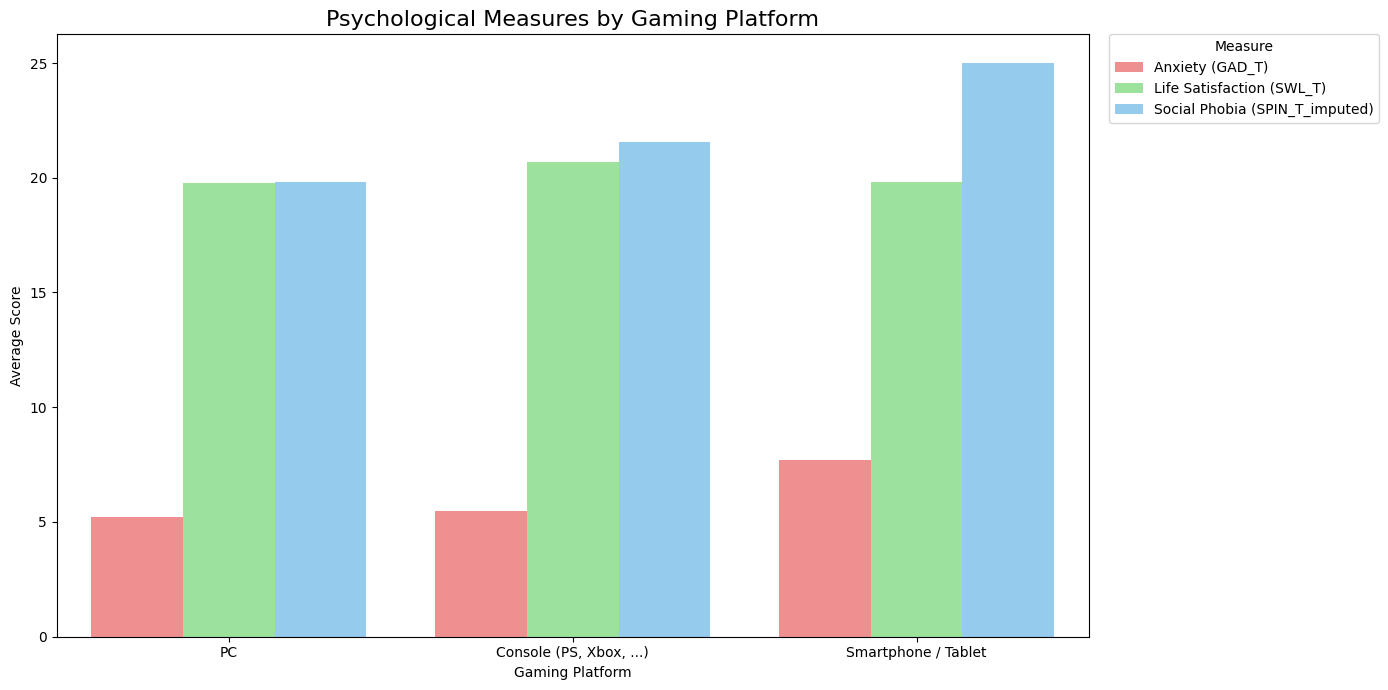

In [23]:
platform_data = gamers_csv.groupby('Platform_encoded')[['GAD_T', 'SWL_T', 'SPIN_T_imputed']].mean().reset_index()

# Define the mapping from numerical platform codes to descriptive labels
# Based on the user's input and observed values in the 'Platform' column (0, 1, 2)
platform_label_map = {
    1: "PC",
    2: "Console (PS, Xbox, ...)",
    3: "Smartphone / Tablet"
}

# Apply the mapping to create a new column with descriptive labels
platform_data['Platform_Label'] = platform_data['Platform_encoded'].map(platform_label_map)

platform_melted = pd.melt(
    platform_data,
    id_vars=['Platform_encoded', 'Platform_Label'], # Include 'Platform_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T_imputed'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T_imputed': '#87CEFA'
}

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=platform_melted,
    x='Platform_Label', # Use the new 'Platform_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Gaming Platform', fontsize=16)
plt.xlabel('Gaming Platform')
plt.ylabel('Average Score')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T_imputed)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('platform_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### SECTION 20: Psychological Measures by Game

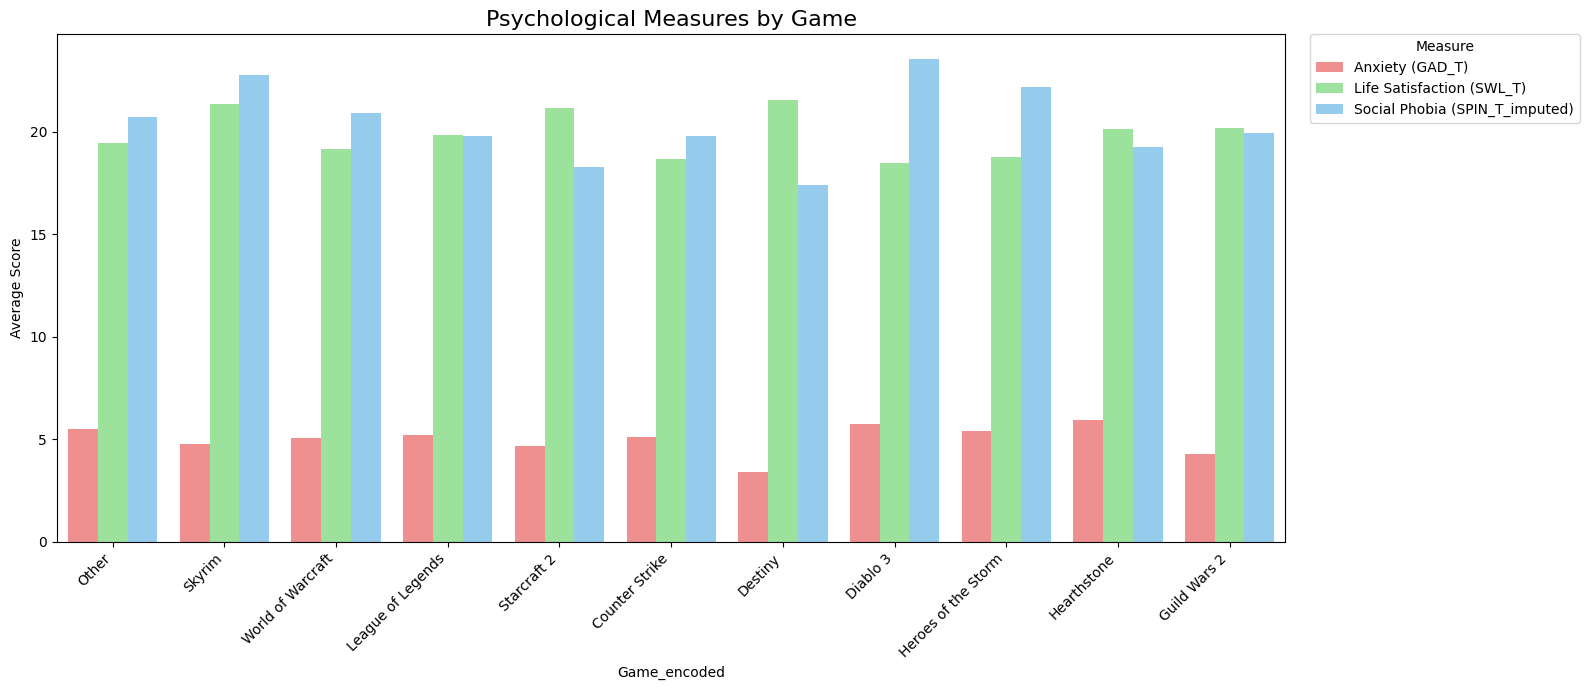

In [24]:
#--------------------Ming--------------------------#
game_data = gamers_csv.groupby('Game_encoded')[['GAD_T', 'SWL_T', 'SPIN_T_imputed']].mean().reset_index()

# Define game code mapping - re-using the one from cell uTvA-L0M3peh
game_code_mapping = {
    0: "Other",
    1: "Skyrim",
    2: "World of Warcraft",
    3: "League of Legends",
    4: "Starcraft 2",
    5: "Counter Strike",
    6: "Destiny",
    7: "Diablo 3",
    8: "Heroes of the Storm",
    9: "Hearthstone",
    10: "Guild Wars 2"
}

# Apply the mapping to create a new column with descriptive labels
game_data['Game_Label'] = game_data['Game_encoded'].map(game_code_mapping).fillna("Unknown")

game_melted = pd.melt(
    game_data,
    id_vars=['Game_encoded', 'Game_Label'], # Include 'Game_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T_imputed'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T_imputed': '#87CEFA'
}

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=game_melted,
    x='Game_Label', # Use the new 'Game_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Game', fontsize=16)
plt.xlabel('Game_encoded')
plt.ylabel('Average Score')

plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T_imputed)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('game_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### SECTION 21: Psychological Measures by Playstyle

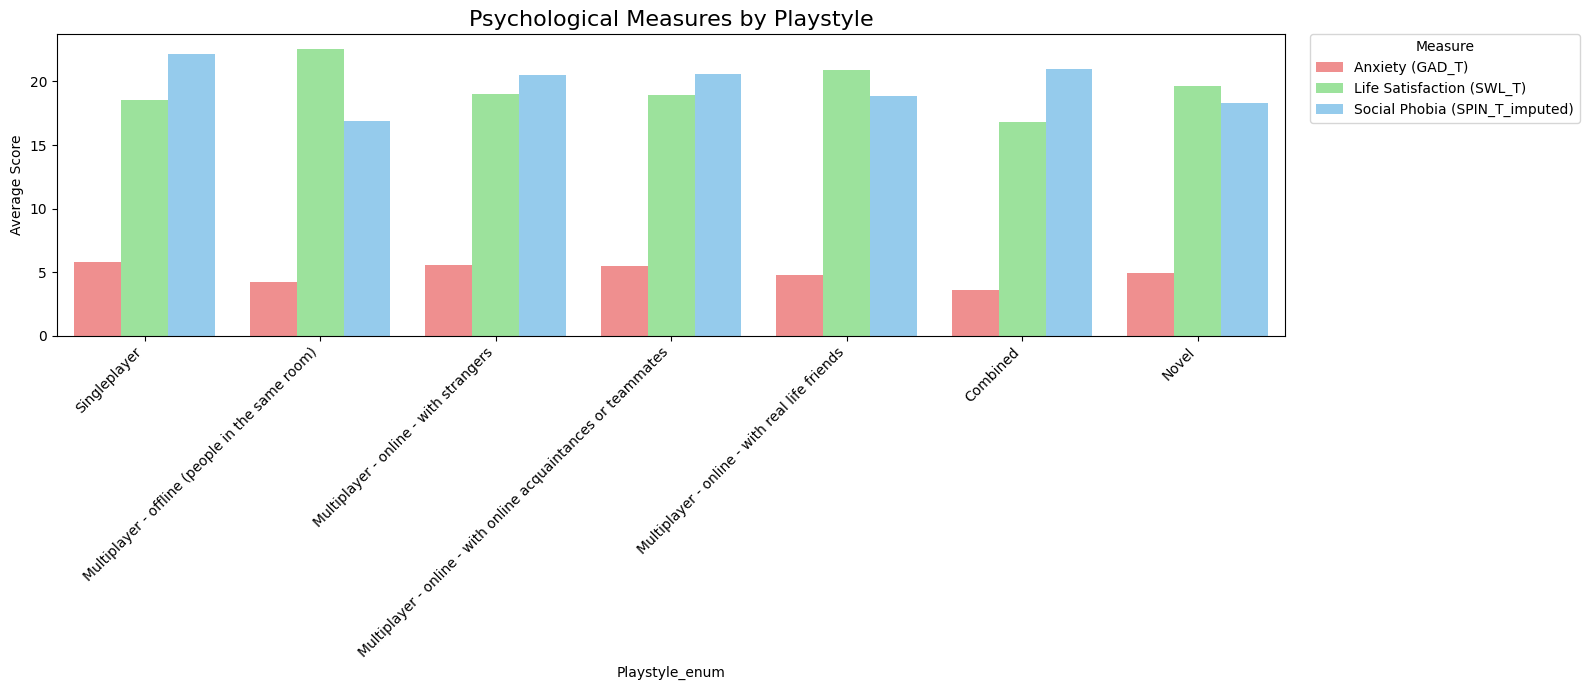

In [25]:
#--------------------Ming--------------------------#
playstyle_data = gamers_csv.groupby('Playstyle_enum')[['GAD_T', 'SWL_T', 'SPIN_T_imputed']].mean().reset_index()

# Define playstyle code mapping
playstyle_mapping = {
    1: "Singleplayer",
    2: "Multiplayer - offline (people in the same room)",
    3: "Multiplayer - online - with strangers",
    4: "Multiplayer - online - with online acquaintances or teammates",
    5: "Multiplayer - online - with real life friends",
    6: "Combined",
    7: "Novel"
}

# Apply the mapping to create a new column with descriptive labels
# Handle case where 'Playstyle' might contain values not in mapping (e.g., 0 from GADE in cell HXgJtjXybCyE)
playstyle_data['Playstyle_Label'] = playstyle_data['Playstyle_enum'].map(playstyle_mapping).fillna("Unknown")

playstyle_melted = pd.melt(
    playstyle_data,
    id_vars=['Playstyle_enum', 'Playstyle_Label'], # Include 'Playstyle_Label' in id_vars
    value_vars=['GAD_T', 'SWL_T', 'SPIN_T_imputed'],
    var_name='Measure',
    value_name='Score'
)

color_map = {
    'GAD_T': '#FF7F7F',
    'SWL_T': '#90EE90',
    'SPIN_T_imputed': '#87CEFA'
}

plt.figure(figsize=(16, 7))
ax = sns.barplot(
    data=playstyle_melted,
    x='Playstyle_Label', # Use the new 'Playstyle_Label' column for the x-axis
    y='Score',
    hue='Measure',
    palette=color_map
)

plt.title('Psychological Measures by Playstyle', fontsize=16)
plt.xlabel('Playstyle_enum')
plt.ylabel('Average Score')

plt.xticks(rotation=45, ha='right')

handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    ['Anxiety (GAD_T)', 'Life Satisfaction (SWL_T)', 'Social Phobia (SPIN_T_imputed)'],
    title='Measure',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.savefig('playstyle_analysis_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### SECTION 22: Relationships of Psychological Measures

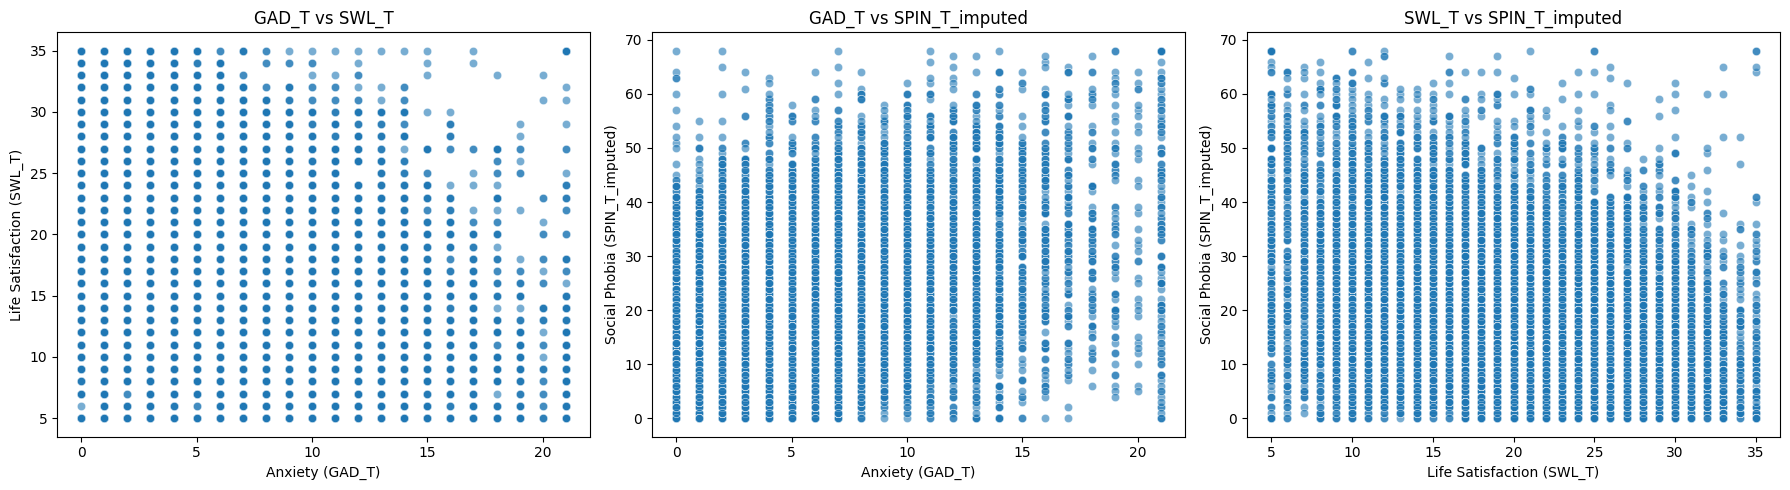

In [26]:
#--------------------Ming--------------------------#
# This cell generates scatter plots to visualize the relationships between the three psychological measures: GAD_T, SWL_T, and SPIN_T.
import matplotlib.pyplot as plt
import seaborn as sns

psych_measures = ['GAD_T', 'SWL_T', 'SPIN_T_imputed']

# Create scatter plots for each pair of psychological measures
plt.figure(figsize=(18, 5))

# GAD_T vs SWL_T
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.scatterplot(x='GAD_T', y='SWL_T', data=gamers_csv, alpha=0.6)
plt.title('GAD_T vs SWL_T')
plt.xlabel('Anxiety (GAD_T)')
plt.ylabel('Life Satisfaction (SWL_T)')

# GAD_T vs SPIN_T_imputed
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.scatterplot(x='GAD_T', y='SPIN_T_imputed', data=gamers_csv, alpha=0.6)
plt.title('GAD_T vs SPIN_T_imputed')
plt.xlabel('Anxiety (GAD_T)')
plt.ylabel('Social Phobia (SPIN_T_imputed)')

# SWL_T vs SPIN_T_imputed
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.scatterplot(x='SWL_T', y='SPIN_T_imputed', data=gamers_csv, alpha=0.6)
plt.title('SWL_T vs SPIN_T_imputed')
plt.xlabel('Life Satisfaction (SWL_T)')
plt.ylabel('Social Phobia (SPIN_T_imputed)')

plt.tight_layout()
plt.show()

#### SECTION 23: OUTLIER DETECTION

In [27]:
#--------------------Riya--------------------------#
# CONFIG
INCLUDE_CATEGORICAL = False
SKIP_ORDINAL = True

categorical_cols = [
    'GADE_encoded','Game_encoded','Platform_encoded','Gender_encoded',
    'Work_encoded','Degree_encoded','Playstyle_enum'
]

ordinal_cols = (
    ['GAD1','GAD2','GAD3','GAD4','GAD5','GAD6','GAD7','GAD_T'] +
    ['SWL1','SWL2','SWL3','SWL4','SWL5','SWL_T'] +
    [f'SPIN{i}_imputed' for i in range(1,18)] + ['SPIN_T_imputed']
)

# SELECT NUMERIC
numeric_cols = gamers_csv.select_dtypes(include=np.number).columns

if not INCLUDE_CATEGORICAL:
    numeric_cols = [c for c in numeric_cols if c not in categorical_cols]

if SKIP_ORDINAL:
    numeric_cols = [c for c in numeric_cols if c not in ordinal_cols]

# OUTLIER FUNCTIONS
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (s < lb) | (s > ub)
    return lb, ub, mask.sum(), mask.mean()*100

def z_outliers(s):
    z = np.abs(stats.zscore(s.dropna()))
    return (z > 3).sum(), (z > 3).mean()*100

# ANALYSIS
results = []

for col in numeric_cols:
    s = gamers_csv[col].dropna()
    if len(s) == 0 or s.nunique() <= 1:
        continue

    lb, ub, iqr_n, iqr_pct = iqr_outliers(s)
    z_n, z_pct = z_outliers(s)

    results.append({
        "Column": col,
        "Count": len(s),
        "Mean": s.mean(),
        "Min": s.min(),
        "Max": s.max(),
        "IQR_Outliers": iqr_n,
        "IQR_%": iqr_pct,
        "Z_Outliers": z_n,
        "Z_%": z_pct
    })

outlier_df = pd.DataFrame(results)

# SUMMARY
print("Top Outlier Columns:")
print(outlier_df.sort_values("IQR_%", ascending=False).head(10))

print("\nOverall:")
total_outliers = outlier_df["IQR_Outliers"].sum()
total_cells = len(gamers_csv) * len(numeric_cols)
print(f"Outlier Rate: {100 * total_outliers / total_cells:.2f}%")

# QUICK CHECKS
print("\nQuick Validations:")

print("Age range:", gamers_csv["Age"].min(), "-", gamers_csv["Age"].max())
print("Hours >168:", (gamers_csv.get("Hours", pd.Series()) > 168).sum())

print("GAD invalid:", ((gamers_csv.filter(like="GAD") > 3) |
                       (gamers_csv.filter(like="GAD") < 0)).sum().sum())

print("SWL invalid:", ((gamers_csv.filter(like="SWL") > 7) |
                       (gamers_csv.filter(like="SWL") < 1)).sum().sum())

print("SPIN invalid:", ((gamers_csv.filter(like="SPIN") > 4) |
                        (gamers_csv.filter(like="SPIN") < 0)).sum().sum())

Top Outlier Columns:
                    Column  Count       Mean   Min    Max  IQR_Outliers  \
5          whyplay_winning  13407   0.164690   0.0    1.0          2208   
7         whyplay_relaxing  13407   0.051540   0.0    1.0           691   
4                      Age  13407  20.934661  18.0   63.0           448   
3                  streams  13407  10.536212   0.0  420.0           445   
21          other_rank_num  13407   0.199821   0.0   21.0           406   
12            sc2_rank_num  13407   0.241217   0.0   20.0           336   
1         earnings_cluster  13407   0.080853   0.0    7.0           314   
10   whyplay_novel_cluster  13407   0.023794   0.0    4.0           263   
13  counterstrike_rank_num  13407   0.146043   0.0   21.0           230   
8         whyplay_combined  13407   0.005743   0.0    1.0            77   

        IQR_%  Z_Outliers       Z_%  
5   16.469009           0  0.000000  
7    5.154024         691  5.154024  
4    3.341538         240  1.790110  
3

TypeError: '>' not supported between instances of 'str' and 'int'

### HYPOTHESES TESTING

In [ ]:

#---------MANASA----------#
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats
from matplotlib.ticker import MaxNLocator

# ==============================================================================
# HYPOTHESIS 1: Higher League ranking vs. high GAD_T and low SWL_T
# ==============================================================================

# -----------------------a) variable readiness----------------------------------
key_cols = ["avg_rank_score", "GAD_T", "SWL_T", "Hours", "Narcissism", "Age",
              "whyplay_relaxing", "whyplay_having_fun"]
# ensure columns have no NA values and numeric types (spot checks)
gamers_csv[key_cols] = gamers_csv[key_cols].apply(pd.to_numeric, errors="coerce")


gamers_csv = gamers_csv.dropna(subset=["avg_rank_score", "GAD_T", "SWL_T"])
print("Shape after numeric coercion:", gamers_csv.shape)

# -----------------------b) EDA for correlations--------------------------------
print("\n=== Spearman Correlations with league_score ===")
for outcome in ["GAD_T", "SWL_T"]:
    spearman_r, spearman_p = stats.spearmanr(gamers_csv["avg_rank_score"], gamers_csv[outcome])
    print(f"{outcome}: Spearman r={spearman_r:.3f}, p={spearman_p:.4g}")

# Boxplots: GAD_T & SWL_T by league_score
# (treated as categorical for visualization)
plt.figure(figsize=(10, 5))
sns.boxplot(x="avg_rank_score", y="GAD_T", data=gamers_csv)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("GAD_T by League Score")
plt.xlabel("League average rank score")
plt.ylabel("GAD_T")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="avg_rank_score", y="SWL_T", data=gamers_csv)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("SWL_T by League Score")
plt.xlabel("League average rank score")
plt.ylabel("SWL_T")
plt.tight_layout()
plt.show()

# Scatter with regression line
for outcome in ["GAD_T", "SWL_T"]:
    plt.figure(figsize=(6, 4))
    sns.regplot(x="avg_rank_score", y=outcome, data=gamers_csv, scatter_kws={"alpha": 0.3})
    plt.title(f"{outcome} vs League average rank score")
    plt.xlabel("League average rank score")
    plt.tight_layout()
    plt.show()


# -----------------------c) Baseline Simple Regressions-------------------------
# Model 1: GAD_T ~ league_score
model1 = smf.ols("GAD_T ~ avg_rank_score", data=gamers_csv).fit()
print("\n=== Baseline Model 1: GAD_T ~ league_score ===")
print(model1.summary())

# Model 2: SWL_T ~ league_score
model2 = smf.ols("SWL_T ~ avg_rank_score", data=gamers_csv).fit()
print("\n=== Baseline Model 2: SWL_T ~ league_score ===")
print(model2.summary())



# -----------------------d) Controlled Multivariate Regressions---------------
controls = (
    "Hours + Age + "
    "C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Game_encoded + Platform_encoded + "
    "whyplay_having_fun + whyplay_winning + whyplay_improving + "
    "whyplay_relaxing"
)

# Model 3: GAD_T ~ league_score + controls
formula3 = f"GAD_T ~ avg_rank_score + {controls}"
model3 = smf.ols(formula3, data=gamers_csv).fit()
print("\n=== Controlled Model 3: GAD_T ~ league_score + controls ===")
print(model3.summary())

# Model 4: SWL_T ~ league_score + controls
formula4 = f"SWL_T ~ avg_rank_score + {controls}"
model4 = smf.ols(formula4, data=gamers_csv).fit()
print("\n=== Controlled Model 4: SWL_T ~ league_score + controls ===")
print(model4.summary())


# -----------------------e) Non-linear & Interaction Models---------------------

# Quadratic term for league_score (possible U-shape)
formula5 = f"GAD_T ~ avg_rank_score + I(avg_rank_score**2) + {controls}"
model5 = smf.ols(formula5, data=gamers_csv).fit()
print("\n=== Model 5: GAD_T ~ avg_rank_score + avg_rank_score^2 + controls ===")
print(model5.summary())

formula6 = f"SWL_T ~ avg_rank_score + I(avg_rank_score**2) + {controls}"
model6 = smf.ols(formula6, data=gamers_csv).fit()
print("\n=== Model 6: SWL_T ~ avg_rank_score + avg_rank_score^2 + controls ===")
print(model6.summary())

# Interaction with Hours (does high rank + high Hours amplify effects?)
formula7 = f"GAD_T ~ avg_rank_score * Hours + {controls.replace('Hours + ', '')}"
model7 = smf.ols(formula7, data=gamers_csv).fit()
print("\n=== Model 7: GAD_T ~ avg_rank_score * Hours + controls (minus duplicate Hours) ===")
print(model7.summary())

formula8 = f"SWL_T ~ avg_rank_score * Hours + {controls.replace('Hours + ', '')}"
model8 = smf.ols(formula8, data=gamers_csv).fit()
print("\n=== Model 8: SWL_T ~ avg_rank_score * Hours + controls (minus duplicate Hours) ===")
print(model8.summary())


# -----------------------f) Group Comparisons (ANOVA-style)---------------------
# Create rank groups: low / mid / high based on tertiles
gamers_csv["rank_group"] = pd.qcut(gamers_csv["avg_rank_score"], q=3,
                                 labels=["Low", "Mid", "High"])

print("\nRank group counts:")
print(gamers_csv["rank_group"].value_counts())

# ANOVA for GAD_T across rank groups
anova_model_gad = smf.ols("GAD_T ~ C(rank_group)", data=gamers_csv).fit()
anova_table_gad = anova_lm(anova_model_gad)
print("\n=== ANOVA: GAD_T ~ rank_group ===")
print(anova_table_gad)

# ANOVA for SWL_T across rank groups
anova_model_swl = smf.ols("SWL_T ~ C(rank_group)", data=gamers_csv).fit()
anova_table_swl = anova_lm(anova_model_swl)
print("\n=== ANOVA: SWL_T ~ rank_group ===")
print(anova_table_swl)

# Visualization of group means
group_means = gamers_csv.groupby("rank_group")[["GAD_T", "SWL_T"]].mean()
print("\nGroup means by rank_group:")
print(group_means)

group_means.plot(kind="bar", figsize=(8, 5))
plt.title("Mean GAD_T & SWL_T by Rank Group")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


# SECTION 24: K-Means Cluster with Hours, Streams, Whyplay, Playstyle

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices = X.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 4 based on the analysis goal.
# ------------------------------------------------------------
k = 4
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster'] = np.nan
gamers_csv.loc[kept_indices, 'Cluster'] = clusters

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters = sns.color_palette('viridis', n_colors=k)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors_for_clusters[label] for label in clusters], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 4) Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means = (
    gamers_csv.loc[kept_indices]
    .groupby('Cluster')[clustering_features]
    .mean()
)

cluster_means.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters) # Pass list of colors
plt.title('Cluster Profiles: Mean Feature Values')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# SECTION 25: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, playstyle, whyplay)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization (including Hours and streams as requested in previous steps)
visualization_features = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices to ensure consistency with the clustering process
# 'kept_indices' was defined in the original clustering step (Section 24) and refers to rows used for clustering.
cluster_psych_means = gamers_csv.loc[kept_indices].groupby('Cluster')[visualization_features].mean()

print("\nMean psychological measures and gaming metrics by cluster:")
display(cluster_psych_means)


# SECTION 26: Motivation Only K-Means Clustering with Whyplay

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features = [
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices = X.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 4 based on the analysis goal.
# ------------------------------------------------------------
k = 4
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster'] = np.nan
gamers_csv.loc[kept_indices, 'Cluster'] = clusters

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters = sns.color_palette('viridis', n_colors=k)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors_for_clusters[label] for label in clusters], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 4) Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means = (
    gamers_csv.loc[kept_indices]
    .groupby('Cluster')[clustering_features]
    .mean()
)

cluster_means.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters) # Pass list of colors
plt.title('Cluster Profiles: Mean Feature Values')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# SECTION 27: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, whyplay)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices to ensure consistency with the clustering process
# 'kept_indices' was defined in the original clustering step (Section 24) and refers to rows used for clustering.
cluster_psych_means = gamers_csv.loc[kept_indices].groupby('Cluster')[visualization_features].mean()

print("\nMean psychological measures and gaming metrics by cluster:")
display(cluster_psych_means)


# SECTION 28: Bahavior Only K-Means Clustering with Hours, Streams, Platform

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features = [
    'Hours',
    'streams',
    'Platform_encoded'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features] = gamers_csv[clustering_features].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X = gamers_csv[clustering_features].copy()
X.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices = X.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 4 based on the analysis goal.
# ------------------------------------------------------------
k = 4
kmeans = KMeans(
    n_clusters=k,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster'] = np.nan
gamers_csv.loc[kept_indices, 'Cluster'] = clusters

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters = sns.color_palette('viridis', n_colors=k)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors_for_clusters[label] for label in clusters], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 4) Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means = (
    gamers_csv.loc[kept_indices]
    .groupby('Cluster')[clustering_features]
    .mean()
)

cluster_means.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters) # Pass list of colors
plt.title('Cluster Profiles: Mean Feature Values')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# SECTION 29: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, platform)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Platform_encoded'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices to ensure consistency with the clustering process
# 'kept_indices' was defined in the original clustering step (Section 24) and refers to rows used for clustering.
cluster_psych_means = gamers_csv.loc[kept_indices].groupby('Cluster')[visualization_features].mean()

print("\nMean psychological measures and gaming metrics by cluster:")
display(cluster_psych_means)


# SECTION 30: K-Means Cluster with Hours, Streams, Whyplay, Playstyle (k=3)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k3_1 = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k3_1] = gamers_csv[clustering_features_k3_1].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k3_1 = gamers_csv[clustering_features_k3_1].copy()
X_k3_1.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k3_1 = X_k3_1.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k3_1 = StandardScaler()
X_scaled_k3_1 = scaler_k3_1.fit_transform(X_k3_1)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 3 for this run.
# ------------------------------------------------------------
k_3 = 3
kmeans_k3_1 = KMeans(
    n_clusters=k_3,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k3_1 = kmeans_k3_1.fit_predict(X_scaled_k3_1)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k3_1'] = np.nan
gamers_csv.loc[kept_indices_k3_1, 'Cluster_k3_1'] = clusters_k3_1

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k3_1 = sns.color_palette('viridis', n_colors=k_3)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k3_1 = PCA(n_components=2, random_state=42)
X_pca_k3_1 = pca_k3_1.fit_transform(X_scaled_k3_1)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k3_1[:, 0],
    X_pca_k3_1[:, 1],
    c=[colors_for_clusters_k3_1[label] for label in clusters_k3_1], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k3_1 = pca_k3_1.transform(kmeans_k3_1.cluster_centers_)
plt.scatter(
    centroids_pca_k3_1[:, 0],
    centroids_pca_k3_1[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 3) Visualized Using PCA (Hours, Streams, Whyplay, Playstyle)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k3_1 = (
    gamers_csv.loc[kept_indices_k3_1]
    .groupby('Cluster_k3_1')[clustering_features_k3_1]
    .mean()
)

cluster_means_k3_1.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k3_1) # Pass list of colors
plt.title('Cluster Profiles (k=3): Mean Feature Values (Hours, Streams, Whyplay, Playstyle)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 31: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, playstyle, whyplay) (k=3)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization (including Hours and streams as requested in previous steps)
visualization_features_k3_1 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k3_1:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k3_1 to ensure consistency with the clustering process
cluster_psych_means_k3_1 = gamers_csv.loc[kept_indices_k3_1].groupby('Cluster_k3_1')[visualization_features_k3_1].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=3 - Hours, Streams, Whyplay, Playstyle):")
display(cluster_psych_means_k3_1)

# SECTION 32: Motivation Only K-Means Clustering with Whyplay (k=3)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k3_2 = [
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k3_2] = gamers_csv[clustering_features_k3_2].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k3_2 = gamers_csv[clustering_features_k3_2].copy()
X_k3_2.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k3_2 = X_k3_2.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k3_2 = StandardScaler()
X_scaled_k3_2 = scaler_k3_2.fit_transform(X_k3_2)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 3 for this run.
# ------------------------------------------------------------
k_3_2 = 3
kmeans_k3_2 = KMeans(
    n_clusters=k_3_2,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k3_2 = kmeans_k3_2.fit_predict(X_scaled_k3_2)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k3_2'] = np.nan
gamers_csv.loc[kept_indices_k3_2, 'Cluster_k3_2'] = clusters_k3_2

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k3_2 = sns.color_palette('viridis', n_colors=k_3_2)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k3_2 = PCA(n_components=2, random_state=42)
X_pca_k3_2 = pca_k3_2.fit_transform(X_scaled_k3_2)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k3_2[:, 0],
    X_pca_k3_2[:, 1],
    c=[colors_for_clusters_k3_2[label] for label in clusters_k3_2], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k3_2 = pca_k3_2.transform(kmeans_k3_2.cluster_centers_)
plt.scatter(
    centroids_pca_k3_2[:, 0],
    centroids_pca_k3_2[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 3) Visualized Using PCA (Whyplay Only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k3_2 = (
    gamers_csv.loc[kept_indices_k3_2]
    .groupby('Cluster_k3_2')[clustering_features_k3_2]
    .mean()
)

cluster_means_k3_2.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k3_2) # Pass list of colors
plt.title('Cluster Profiles (k=3): Mean Feature Values (Whyplay Only)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 33: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, whyplay) (k=3)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features_k3_2 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k3_2:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k3_2 to ensure consistency with the clustering process
cluster_psych_means_k3_2 = gamers_csv.loc[kept_indices_k3_2].groupby('Cluster_k3_2')[visualization_features_k3_2].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=3 - Whyplay Only):")
display(cluster_psych_means_k3_2)

# SECTION 34: Behavior Only K-Means Clustering with Hours, Streams, Platform (k=3)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k3_3 = [
    'Hours',
    'streams',
    'Platform_encoded'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k3_3] = gamers_csv[clustering_features_k3_3].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k3_3 = gamers_csv[clustering_features_k3_3].copy()
X_k3_3.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k3_3 = X_k3_3.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k3_3 = StandardScaler()
X_scaled_k3_3 = scaler_k3_3.fit_transform(X_k3_3)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 3 for this run.
# ------------------------------------------------------------
k_3_3 = 3
kmeans_k3_3 = KMeans(
    n_clusters=k_3_3,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k3_3 = kmeans_k3_3.fit_predict(X_scaled_k3_3)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k3_3'] = np.nan
gamers_csv.loc[kept_indices_k3_3, 'Cluster_k3_3'] = clusters_k3_3

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k3_3 = sns.color_palette('viridis', n_colors=k_3_3)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k3_3 = PCA(n_components=2, random_state=42)
X_pca_k3_3 = pca_k3_3.fit_transform(X_scaled_k3_3)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k3_3[:, 0],
    X_pca_k3_3[:, 1],
    c=[colors_for_clusters_k3_3[label] for label in clusters_k3_3], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k3_3 = pca_k3_3.transform(kmeans_k3_3.cluster_centers_)
plt.scatter(
    centroids_pca_k3_3[:, 0],
    centroids_pca_k3_3[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 3) Visualized Using PCA (Hours, Streams, Platform)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k3_3 = (
    gamers_csv.loc[kept_indices_k3_3]
    .groupby('Cluster_k3_3')[clustering_features_k3_3]
    .mean()
)

cluster_means_k3_3.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k3_3) # Pass list of colors
plt.title('Cluster Profiles (k=3): Mean Feature Values (Hours, Streams, Platform)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 35: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, platform) (k=3)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features_k3_3 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Platform_encoded'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k3_3:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k3_3 to ensure consistency with the clustering process
cluster_psych_means_k3_3 = gamers_csv.loc[kept_indices_k3_3].groupby('Cluster_k3_3')[visualization_features_k3_3].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=3 - Hours, Streams, Platform):")
display(cluster_psych_means_k3_3)

# SECTION 36: K-Means Cluster with Hours, Streams, Whyplay, Playstyle (k=7)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k7_1 = [
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k7_1] = gamers_csv[clustering_features_k7_1].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k7_1 = gamers_csv[clustering_features_k7_1].copy()
X_k7_1.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k7_1 = X_k7_1.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k7_1 = StandardScaler()
X_scaled_k7_1 = scaler_k7_1.fit_transform(X_k7_1)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 7 for this run.
# ------------------------------------------------------------
k_7 = 7
kmeans_k7_1 = KMeans(
    n_clusters=k_7,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k7_1 = kmeans_k7_1.fit_predict(X_scaled_k7_1)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k7_1'] = np.nan
gamers_csv.loc[kept_indices_k7_1, 'Cluster_k7_1'] = clusters_k7_1

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k7_1 = sns.color_palette('viridis', n_colors=k_7)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k7_1 = PCA(n_components=2, random_state=42)
X_pca_k7_1 = pca_k7_1.fit_transform(X_scaled_k7_1)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k7_1[:, 0],
    X_pca_k7_1[:, 1],
    c=[colors_for_clusters_k7_1[label] for label in clusters_k7_1], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k7_1 = pca_k7_1.transform(kmeans_k7_1.cluster_centers_)
plt.scatter(
    centroids_pca_k7_1[:, 0],
    centroids_pca_k7_1[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 7) Visualized Using PCA (Hours, Streams, Whyplay, Playstyle)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k7_1 = (
    gamers_csv.loc[kept_indices_k7_1]
    .groupby('Cluster_k7_1')[clustering_features_k7_1]
    .mean()
)

cluster_means_k7_1.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k7_1) # Pass list of colors
plt.title('Cluster Profiles (k=7): Mean Feature Values (Hours, Streams, Whyplay, Playstyle)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 37: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, playstyle, whyplay) (k=7)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization (including Hours and streams as requested in previous steps)
visualization_features_k7_1 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Playstyle_enum',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k7_1:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k7_1 to ensure consistency with the clustering process
cluster_psych_means_k7_1 = gamers_csv.loc[kept_indices_k7_1].groupby('Cluster_k7_1')[visualization_features_k7_1].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=7 - Hours, Streams, Whyplay, Playstyle):")
display(cluster_psych_means_k7_1)

# SECTION 38: Motivation Only K-Means Clustering with Whyplay (k=7)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k7_2 = [
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k7_2] = gamers_csv[clustering_features_k7_2].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k7_2 = gamers_csv[clustering_features_k7_2].copy()
X_k7_2.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k7_2 = X_k7_2.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k7_2 = StandardScaler()
X_scaled_k7_2 = scaler_k7_2.fit_transform(X_k7_2)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 7 for this run.
# ------------------------------------------------------------
k_7_2 = 7
kmeans_k7_2 = KMeans(
    n_clusters=k_7_2,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k7_2 = kmeans_k7_2.fit_predict(X_scaled_k7_2)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k7_2'] = np.nan
gamers_csv.loc[kept_indices_k7_2, 'Cluster_k7_2'] = clusters_k7_2

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k7_2 = sns.color_palette('viridis', n_colors=k_7_2)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k7_2 = PCA(n_components=2, random_state=42)
X_pca_k7_2 = pca_k7_2.fit_transform(X_scaled_k7_2)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k7_2[:, 0],
    X_pca_k7_2[:, 1],
    c=[colors_for_clusters_k7_2[label] for label in clusters_k7_2], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k7_2 = pca_k7_2.transform(kmeans_k7_2.cluster_centers_)
plt.scatter(
    centroids_pca_k7_2[:, 0],
    centroids_pca_k7_2[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 7) Visualized Using PCA (Whyplay Only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k7_2 = (
    gamers_csv.loc[kept_indices_k7_2]
    .groupby('Cluster_k7_2')[clustering_features_k7_2]
    .mean()
)

cluster_means_k7_2.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k7_2) # Pass list of colors
plt.title('Cluster Profiles (k=7): Mean Feature Values (Whyplay Only)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 39: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, whyplay) (k=7)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features_k7_2 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'whyplay_winning',
    'whyplay_improving',
    'whyplay_relaxing',
    'whyplay_having_fun',
    'whyplay_combined',
    'whyplay_novel'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k7_2:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k7_2 to ensure consistency with the clustering process
cluster_psych_means_k7_2 = gamers_csv.loc[kept_indices_k7_2].groupby('Cluster_k7_2')[visualization_features_k7_2].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=7 - Whyplay Only):")
display(cluster_psych_means_k7_2)

# SECTION 40: Behavior Only K-Means Clustering with Hours, Streams, Platform (k=7)

In [ ]:
#--------------------Ming--------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palette generation

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Define features used for K-means clustering
# Only numeric variables are included to ensure distance-based
# clustering is meaningful.
# ------------------------------------------------------------
clustering_features_k7_3 = [
    'Hours',
    'streams',
    'Platform_encoded'
]

# ------------------------------------------------------------
# Step 2: Ensure all clustering features are numeric
# Non-numeric values are coerced to NaN for consistency.
# ------------------------------------------------------------
gamers_csv[clustering_features_k7_3] = gamers_csv[clustering_features_k7_3].apply(
    pd.to_numeric, errors='coerce'
)

# ------------------------------------------------------------
# Step 3: Create the feature matrix and remove rows with
# missing values in any clustering feature.
# ------------------------------------------------------------
X_k7_3 = gamers_csv[clustering_features_k7_3].copy()
X_k7_3.dropna(inplace=True)

# Store indices of rows retained for clustering
kept_indices_k7_3 = X_k7_3.index

# ------------------------------------------------------------
# Step 4: Standardize features
# Standardization is required because K-means relies on
# Euclidean distance, and variables are on different scales.
# ------------------------------------------------------------
scaler_k7_3 = StandardScaler()
X_scaled_k7_3 = scaler_k7_3.fit_transform(X_k7_3)

# ------------------------------------------------------------
# Step 5: Perform K-means clustering
# The number of clusters is set to 7 for this run.
# ------------------------------------------------------------
k_7_3 = 7
kmeans_k7_3 = KMeans(
    n_clusters=k_7_3,
    n_init=50,
    random_state=42,
    init='k-means++'
)

clusters_k7_3 = kmeans_k7_3.fit_predict(X_scaled_k7_3)

# ------------------------------------------------------------
# Step 6: Assign cluster labels back to the original DataFrame
# Cluster labels are aligned using the retained row indices.
# ------------------------------------------------------------
gamers_csv['Cluster_k7_3'] = np.nan
gamers_csv.loc[kept_indices_k7_3, 'Cluster_k7_3'] = clusters_k7_3

# ------------------------------------------------------------
# Define a consistent discrete color palette for all plots
colors_for_clusters_k7_3 = sns.color_palette('viridis', n_colors=k_7_3)

# ------------------------------------------------------------
# Step 7: Visualize clustering results using PCA
# PCA is applied only for visualization purposes, reducing
# the high-dimensional feature space to two dimensions.
# ------------------------------------------------------------
pca_k7_3 = PCA(n_components=2, random_state=42)
X_pca_k7_3 = pca_k7_3.fit_transform(X_scaled_k7_3)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca_k7_3[:, 0],
    X_pca_k7_3[:, 1],
    c=[colors_for_clusters_k7_3[label] for label in clusters_k7_3], # Use discrete colors directly
    s=12,
    alpha=0.6
)

# Project cluster centroids into PCA space
centroids_pca_k7_3 = pca_k7_3.transform(kmeans_k7_3.cluster_centers_)
plt.scatter(
    centroids_pca_k7_3[:, 0],
    centroids_pca_k7_3[:, 1],
    marker='X',
    s=200,
    color='red' # Centroids can be a distinct color
)

plt.title('K-means Clusters (k = 7) Visualized Using PCA (Hours, Streams, Platform)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Step 8: Compute and visualize mean feature values by cluster
# This plot is used for cluster profiling and interpretation.
# ------------------------------------------------------------
cluster_means_k7_3 = (
    gamers_csv.loc[kept_indices_k7_3]
    .groupby('Cluster_k7_3')[clustering_features_k7_3]
    .mean()
)

cluster_means_k7_3.T.plot(kind='bar', figsize=(12, 6), color=colors_for_clusters_k7_3) # Pass list of colors
plt.title('Cluster Profiles (k=7): Mean Feature Values (Hours, Streams, Platform)')
plt.ylabel('Mean Value')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# SECTION 41: Cluster Analysis Results (GAD_T, SWL_T, SPIN_T_imputed, Hours, streams, platform) (k=7)

In [ ]:
#--------------------Ming--------------------------#
# Define the features for visualization
visualization_features_k7_3 = [
    'GAD_T',
    'SWL_T',
    'SPIN_T_imputed',
    'Hours',
    'streams',
    'Platform_encoded'
]

# Ensure these columns are numeric, coercing errors to NaN
for col in visualization_features_k7_3:
    gamers_csv[col] = pd.to_numeric(gamers_csv[col], errors='coerce')

# Calculate the mean values for the visualization features for each cluster
# Use kept_indices_k7_3 to ensure consistency with the clustering process
cluster_psych_means_k7_3 = gamers_csv.loc[kept_indices_k7_3].groupby('Cluster_k7_3')[visualization_features_k7_3].mean()

print("\nMean psychological measures and gaming metrics by cluster (k=7 - Hours, Streams, Platform):")
display(cluster_psych_means_k7_3)